# BADGE Sampling on Central Peak Generator

This notebook demonstrates BADGE (Batch Active learning by Diverse Gradient Embeddings) sampling using the `BADGESampler` on synthetic central peak data in 1D and 2D. It visualizes the acquisition function and selected points to verify correctness.

## Import Required Libraries

In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

from UBAS.samplers.badge_sampler import BADGESampler
from UBAS.generators.central_peak_generator import CentralPeakGenerator
from UBAS.generators.input_generator import InputGenerator
from uqregressors.bayesian.deep_ens import DeepEnsembleRegressor
from uqregressors.metrics.metrics import compute_all_metrics

import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

class FigPreset:
    def __init__(self, figsize, dpi, context, font_scale,
                 linewidth, markersize, labelsize, ticksize, titlesize, 
                 legendsize):
        self.figsize = figsize
        self.dpi = dpi
        self.context = context
        self.font_scale = font_scale
        self.linewidth = linewidth
        self.markersize = markersize
        self.labelsize = labelsize
        self.ticksize = ticksize
        self.titlesize = titlesize
        self.legendsize=legendsize

    def apply(self):
        sns.set_context(self.context, font_scale=self.font_scale)
        sns.set_style("ticks")
        return self

# Define presets
FULL_FIG = FigPreset((6, 4.5), 300, "paper", 1.2, 2.5, 8, 20, 14, 20, 16)
HALF_FIG = FigPreset((4, 3), 300, "paper", 1.1, 2.0, 6, 14, 12, 18, 12)
SQUARE_FIG = FigPreset((3, 3), 300, "paper", 1.0, 1.8, 5, 12, 10, 16, 12)
DOUBLE_FIG = FigPreset((12, 4.5), 300, "paper", 1.2, 2.5, 8, 20, 14, 20, 16)


## Set Up Central Peak Generator

In [2]:
# Initialize the Central Peak Generator
generator = CentralPeakGenerator()  # Low noise for clear peak

# Parameters
ndim_1d = 1
ndim_2d = 2
init_points_1d = 5
init_points_2d = 25
bounds_1d = np.array([[-1], [1]])
bounds_2d = np.array([[-1, -1], [1, 1]])

# Generate initial data for 1D
input_sampler_1d = InputGenerator(bounds_1d, ndim_1d, seed=42)
init_inputs_1d, init_targets_1d = generator.generate(input_sampler_1d.uniformly_sample(init_points_1d))

# Generate initial data for 2D
input_sampler_2d = InputGenerator(bounds_2d, ndim_2d, seed=42)
init_inputs_2d, init_targets_2d = generator.generate(input_sampler_2d.uniformly_sample(init_points_2d))

print("Initial 1D inputs shape:", init_inputs_1d.shape)
print("Initial 2D inputs shape:", init_inputs_2d.shape)

Initial 1D inputs shape: (5, 1)
Initial 2D inputs shape: (25, 2)


## Initialize BADGE Sampler for 1D

In [14]:
from UBAS.samplers.grubs_sampler import GRUBSSampler
# Set up regressor for 1D
regressor_1d = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[25, 25], epochs=500, learning_rate=0.001, batch_size=32)

# Initialize BADGE Sampler for 1D
badge_sampler_1d = GRUBSSampler(
    directory="./results/GRUBS_1d",
    regressor=regressor_1d,
    generator=generator,
    bounds=bounds_1d,
    n_iterations=1,
    n_batch_points=5,
    initial_inputs=init_inputs_1d,
    initial_targets=init_targets_1d,
    random_seed=42,
    n_initial_samples=1000,
    n_to_optimize=5,
    optimization_steps=10,
    opt_lr=0.001
)

## Plot Acquisition Function and Selected Points for 1D

In [13]:
def sample_step_with_tracking(sampler):
    """
    Modified version of sample_step that tracks acquisition values at each iteration.
    Returns: list of dicts containing acquisition values and selected indices at each step.
    """
    selected_xs = []
    iteration_data = []
    
    if hasattr(sampler.regressor, "n_gradients"):
        num_models = sampler.regressor.n_gradients
    elif hasattr(sampler.regressor, "models"):
        num_models = len(sampler.regressor.models)
    elif hasattr(sampler.regressor, "model"):
        num_models = 1
    else:
        raise ValueError(f"Regressor of type {sampler.regressor.__class__} does not have model or models attribute")
    
    G_selected = [[] for _ in range(num_models)]
    Q = [None for _ in range(num_models)]
    dim = sampler.regressor.input_dim
    
    # For 1D, precompute acquisition grid in original (unscaled) space
    if dim == 1:
        x_grid = np.linspace(sampler.bounds[0, 0], sampler.bounds[1, 0], 200).reshape(-1, 1)
    
    i = 0
    while i < sampler.n_batch_points:
        print(f"Selecting point: {i+1}/{sampler.n_batch_points}")
        
        # Compute acquisition on grid for this iteration
        acq_values = []
        if dim == 1:
            for x in x_grid:
                # Scale the point for prediction
                x_scaled = sampler.input_scaler.transform(x.reshape(1, -1))
                x_tensor = torch.tensor(x_scaled, dtype=torch.float32)
                grads = sampler.regressor.return_last_layer_grads(x_tensor)
                
                residual_norms = []
                for m, g_x in enumerate(grads): 
                    if Q[m] is None: 
                        residual=g_x 
                    else: 
                        residual = sampler._orthogonal_comp(g_x, Q[m])
                    residual_norms.append(residual.norm())
                    
                avg_residual_norm = sum(residual_norms) / len(residual_norms)
                mean, lower, upper = sampler.regressor.predict(x_tensor)
                z = norm.ppf(1 - sampler.regressor.alpha / 2)
                std = (upper - lower) / (2 * z) * 10**2
                var = std**2
                
                acq = avg_residual_norm * var
                acq_values.append(acq.item())
        
        # Find best point using original optimization (returns scaled [0,1] point)
        best_x_scaled = sampler._optimize_acquisition(dim, Q, sampler.n_initial_samples, sampler.n_to_optimize, 
                                              sampler.optimization_steps, sampler.opt_lr)
        
        if best_x_scaled is None:
            print("Warning: Optimization failed: trying again.")
            continue
        
        # Inverse transform to original space for storage
        best_x = sampler.input_scaler.inverse_transform(best_x_scaled.reshape(1, -1))[0]
        selected_xs.append(best_x)
        
        # Get gradients using scaled point
        grads_sel = sampler.regressor.return_last_layer_grads(torch.tensor(best_x_scaled.reshape(1, -1), dtype=torch.float32))
        
        # Update Q matrices
        for m in range(num_models):
            G_selected[m].append(grads_sel[m])
            G_mat = torch.stack(G_selected[m], dim=0)
            Q_new, _ = torch.linalg.qr(G_mat.T, mode='reduced')
            Q[m] = Q_new
        
        # Store iteration data (with unscaled selected point)
        if dim == 1:
            iteration_data.append({
                'iteration': i,
                'selected_point': best_x.copy(),
                'acq_values': np.array(acq_values),
                'x_grid': x_grid.copy(),
                'Q_matrices': [Q[m].detach().cpu().numpy() if Q[m] is not None else None for m in range(num_models)]
            })
        
        print(f"Selected point {i+1}: {best_x}")
        i += 1
    
    return np.array(selected_xs), iteration_data


## Run 1D Sampling with Per-Iteration Tracking

In [17]:
# Create a fresh 1D sampler for per-iteration tracking
regressor_1d_tracking = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[25, 25], epochs=500, learning_rate=0.001, batch_size=32)

badge_sampler_1d_tracking = GRUBSSampler(
    directory="./results/GRUBS_1d_tracking",
    regressor=regressor_1d_tracking,
    generator=generator,
    bounds=bounds_1d,
    n_iterations=0,  # Set to 0, we'll only do sample_step
    n_batch_points=5,
    initial_inputs=init_inputs_1d,
    initial_targets=init_targets_1d,
    random_seed=42,
    n_initial_samples=1000,
    n_to_optimize=5,
    optimization_steps=10,
    opt_lr=0.001
)

# Train the regressor on initial data
badge_sampler_1d_tracking.regressor.fit(
    badge_sampler_1d_tracking.input_scaler.transform(init_inputs_1d), 
    badge_sampler_1d_tracking.output_scaler.transform(init_targets_1d.reshape(-1, 1))
)

# Run sampling with per-iteration tracking
print("Running 1D sampling with per-iteration tracking...")
selected_points_1d_tracked, iteration_data_1d = sample_step_with_tracking(badge_sampler_1d_tracking)
print("Sampling complete. Generated", len(iteration_data_1d), "iterations.")

Running 1D sampling with per-iteration tracking...
Selecting point: 1/5
Selected point 1: [-0.3261578]
Selecting point: 2/5
Selected point 2: [0.0820936]
Selecting point: 3/5
Selected point 3: [-1.]
Selecting point: 4/5
Selected point 4: [1.]
Selecting point: 5/5
Selected point 5: [-0.5059521]
Sampling complete. Generated 5 iterations.


## Plot Per-Iteration Acquisition and Selected Points for 1D

In [59]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_iterations_comparison(
    iteration_data,
    sampler,
    all_selected_points,
    iters=[1, 2, 5],
    preset=DOUBLE_FIG
):
    """Plot multiple iterations side-by-side with shared legend."""
    
    preset.apply()
    
    n_cols = len(iters)
    
    fig, axes = plt.subplots(
        2, n_cols,
        figsize=(3.5 * n_cols, 4.5),  # much tighter width
        dpi=preset.dpi,
        sharex='col',
        gridspec_kw={'height_ratios': [1, 1.5]}
    )
    
    regressor = sampler.regressor
    bounds = sampler.bounds
    train_X = sampler.initial_inputs
    train_y = sampler.initial_targets
    
    legend_handles = []
    legend_labels = []
    
    for col, iteration_idx in enumerate(iters):
        data = iteration_data[iteration_idx]
        x_grid = data['x_grid']
        acq_values = data['acq_values']
        selected_point = data['selected_point']
        
        ax_top = axes[0, col]
        ax_bot = axes[1, col]
        
        # =========================
        # TOP: Acquisition
        # =========================
        l_acq, = ax_top.plot(
            x_grid.flatten(),
            acq_values,
            color='black',
            linestyle='--',
            linewidth=preset.linewidth,
            label="Acquisition"
        )
        
        if iteration_idx > 0:
            prev_points = all_selected_points[:iteration_idx]
            prev_indices = [
                int((p - bounds[0,0]) / (bounds[1,0]-bounds[0,0]) * (len(acq_values)-1))
                for p in prev_points.flatten()
            ]
            prev_indices = [min(max(idx, 0), len(acq_values)-1) for idx in prev_indices]
            
            s_prev = ax_top.scatter(
                prev_points.flatten(),
                [acq_values[i] for i in prev_indices],
                color='C0',
                s=preset.markersize**2,
                marker="s",
                label="Previous Samples",
                zorder=5
            )
        
        selected_idx = int((selected_point[0] - bounds[0,0]) /
                           (bounds[1,0]-bounds[0,0]) * (len(acq_values)-1))
        selected_idx = min(max(selected_idx, 0), len(acq_values)-1)
        
        s_curr = ax_top.scatter(
            [selected_point[0]],
            [acq_values[selected_idx]],
            color='C1',
            s=preset.markersize**2,
            label="Current Sample",
            zorder=6
        )
        
        ax_top.set_title(f"Iteration {iteration_idx + 1}", fontsize=preset.titlesize)
        ax_top.grid(True, alpha=0.3)
        
        # =========================
        # BOTTOM: Prediction
        # =========================
        x_grid_scaled = sampler.input_scaler.transform(x_grid)
        preds = regressor.predict(torch.tensor(x_grid_scaled, dtype=torch.float32))
        mean, lower, upper = preds
        
        mean = sampler.output_scaler.inverse_transform(mean.reshape(-1, 1))
        lower = sampler.output_scaler.inverse_transform(lower.reshape(-1, 1))
        upper = sampler.output_scaler.inverse_transform(upper.reshape(-1, 1))
        
        l_pred, = ax_bot.plot(
            x_grid.flatten(),
            mean.flatten(),
            color='black',
            linewidth=preset.linewidth,
            label="Prediction"
        )
        
        fb = ax_bot.fill_between(
            x_grid.flatten(),
            lower.flatten(),
            upper.flatten(),
            color='gray',
            alpha=0.6,
            label="90% CI"
        )
        
        s_train = ax_bot.scatter(
            train_X.flatten(),
            train_y.flatten(),
            color='black',
            s=preset.markersize**2,
            label="Training Data",
            zorder=4
        )
        
        if iteration_idx > 0:
            prev_points = all_selected_points[:iteration_idx]
            prev_scaled = sampler.input_scaler.transform(prev_points)
            prev_preds = regressor.predict(torch.tensor(prev_scaled, dtype=torch.float32))
            prev_mean = sampler.output_scaler.inverse_transform(prev_preds[0].reshape(-1, 1))
            
            ax_bot.scatter(
                prev_points.flatten(),
                prev_mean.flatten(),
                color='C0',
                s=preset.markersize**2,
                marker="s",
                zorder=5, 
            )
        
        selected_scaled = sampler.input_scaler.transform(selected_point.reshape(1, -1))
        selected_pred = regressor.predict(torch.tensor(selected_scaled, dtype=torch.float32))
        selected_mean = sampler.output_scaler.inverse_transform(selected_pred[0].reshape(-1, 1))
        
        ax_bot.scatter(
            [selected_point[0]],
            selected_mean.flatten(),
            color='C1',
            s=preset.markersize**2,
            zorder=6
        )
        
        ax_bot.grid(True, alpha=0.3)
        
        # Save legend handles once
        if col == 0:
            legend_handles = [l_acq, l_pred, fb, s_train, s_curr]
            legend_labels = [h.get_label() for h in legend_handles]
            
            # Only add previous samples if they exist
            if iteration_idx > 0:
                legend_handles.insert(4, s_prev)
                legend_labels.insert(4, s_prev.get_label())
    
    # Axis labels (only leftmost & bottom)
    axes[0, 0].set_ylabel("Acquisition", fontsize=preset.labelsize)
    axes[1, 0].set_ylabel("Output y", fontsize=preset.labelsize)
    
    for ax in axes[1]:
        ax.set_xlabel("Input x", fontsize=preset.labelsize)
        ax.tick_params(axis='both', labelsize=preset.ticksize)
    for ax in axes[0]: 
        ax.tick_params(axis='both', labelsize=preset.ticksize)
    # =========================
    # Single Global Legend
    # =========================
    # =========================
    # Global Legend (Manual)
    # =========================
    legend_elements = [
        Line2D([0], [0], color='black', linestyle='--', linewidth=preset.linewidth, label='Acquisition'),
        Line2D([0], [0], color='black', linewidth=preset.linewidth, label='Prediction'),
        Patch(facecolor='gray', alpha=0.6, label='90% Confidence Interval'),
        Line2D([0], [0], marker='o', color='black', linestyle='None',
            markersize=preset.markersize, label='Initial Samples'),
        Line2D([0], [0], marker='s', color='C0', linestyle='None',
            markersize=preset.markersize, label='Previous Samples'),
        Line2D([0], [0], marker='o', color='C1', linestyle='None',
            markersize=preset.markersize, label='Current Sample'),
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        fontsize=preset.legendsize,
        bbox_to_anchor=(0.5, -0.02),  # push below figure
        frameon=False
    )
    
    sns.despine()
    plt.tight_layout(rect=[0, 0.10, 1, 1])  # leave space at bottom
    plt.show()

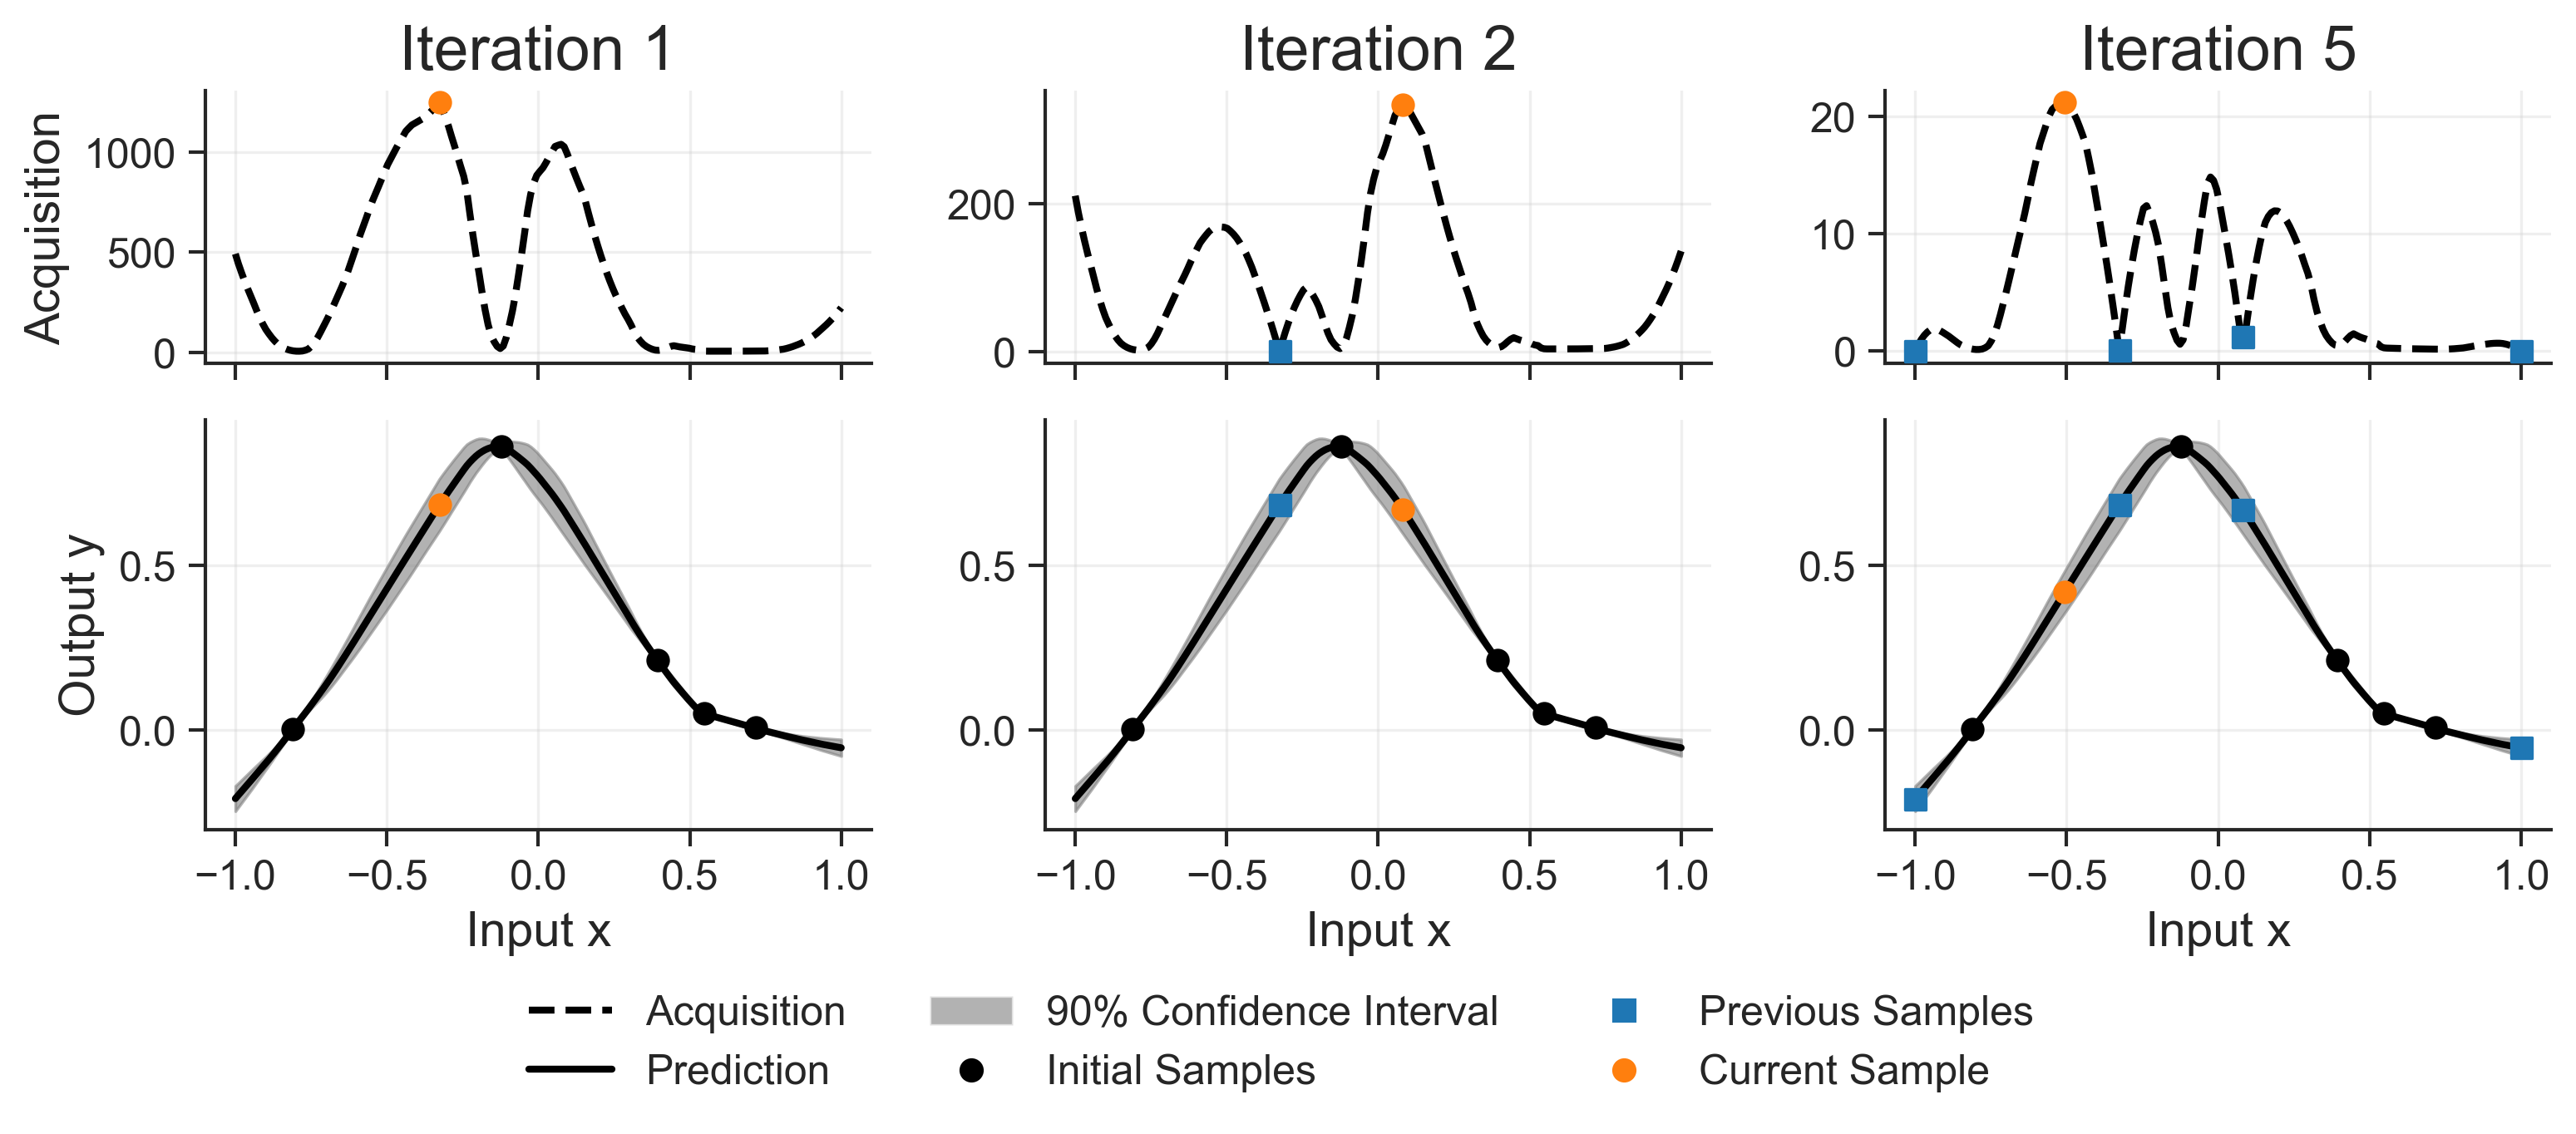

In [60]:
plot_iterations_comparison(
    iteration_data_1d,
    badge_sampler_1d_tracking,
    selected_points_1d_tracked,
    iters=[0, 1, 4],
    preset=HALF_FIG
)

## Initialize BADGE Sampler for 2D

In [3]:
# Set up regressor for 2D
from UBAS.samplers.grubs_sampler import GRUBSSampler
regressor_2d = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[100, 100], epochs=500, learning_rate=0.001, batch_size=32)

# Initialize BADGE Sampler for 2D
badge_sampler_2d = GRUBSSampler(
    directory="./results/GRUBS_2d",
    regressor=regressor_2d,
    generator=generator,
    bounds=bounds_2d,
    n_iterations=1,
    n_batch_points=5,
    initial_inputs=init_inputs_2d,
    initial_targets=init_targets_2d,
    random_seed=42,
    n_initial_samples=1000,
    n_to_optimize=5,
    optimization_steps=10,
    opt_lr=0.001
)

## Run Adaptive Sampling for 2D

## Helper: Track Acquisition Values During 2D Batch Sampling

In [4]:
def sample_step_with_tracking_2d(sampler):
    """
    Modified version of sample_step that tracks acquisition values at each iteration for 2D.
    Returns: list of dicts containing acquisition values and selected indices at each step.
    """
    selected_xs = []
    iteration_data = []
    
    if hasattr(sampler.regressor, "n_gradients"):
        num_models = sampler.regressor.n_gradients
    elif hasattr(sampler.regressor, "models"):
        num_models = len(sampler.regressor.models)
    elif hasattr(sampler.regressor, "model"):
        num_models = 1
    else:
        raise ValueError(f"Regressor of type {sampler.regressor.__class__} does not have model or models attribute")
    
    G_selected = [[] for _ in range(num_models)]
    Q = [None for _ in range(num_models)]
    dim = sampler.regressor.input_dim
    
    # For 2D, precompute acquisition grid in original (unscaled) space
    if dim == 2:
        x1 = np.linspace(sampler.bounds[0, 0], sampler.bounds[1, 0], 40)
        x2 = np.linspace(sampler.bounds[0, 1], sampler.bounds[1, 1], 40)
        X1, X2 = np.meshgrid(x1, x2)
        grid_points = np.column_stack([X1.ravel(), X2.ravel()])
        X1_orig = X1.copy()
        X2_orig = X2.copy()
    
    i = 0
    while i < sampler.n_batch_points:
        print(f"Selecting point: {i+1}/{sampler.n_batch_points}")
        
        # Compute acquisition on grid for this iteration
        acq_values = []
        if dim == 2:
            for point in grid_points:
                # Scale the point for prediction
                point_scaled = sampler.input_scaler.transform(point.reshape(1, -1))
                point_tensor = torch.tensor(point_scaled, dtype=torch.float32)
                grads = sampler.regressor.return_last_layer_grads(point_tensor)
                
                residual_norms = []
                for m, g_x in enumerate(grads): 
                    if Q[m] is None: 
                        residual = g_x 
                    else: 
                        residual = sampler._orthogonal_comp(g_x, Q[m])
                    residual_norms.append(residual.norm())
                    
                avg_residual_norm = sum(residual_norms) / len(residual_norms)
                mean, lower, upper = sampler.regressor.predict(point_tensor)
                z = norm.ppf(1 - sampler.regressor.alpha / 2)
                std = (upper - lower) / (2 * z) * 10**2
                var = std**2
                
                acq = avg_residual_norm * var
                acq_values.append(acq.item())
        
        # Find best point using original optimization (returns scaled [0,1] point)
        best_x_scaled = sampler._optimize_acquisition(dim, Q, sampler.n_initial_samples, sampler.n_to_optimize, 
                                              sampler.optimization_steps, sampler.opt_lr)
        
        if best_x_scaled is None:
            print("Warning: Optimization failed: trying again.")
            continue
        
        # Inverse transform to original space for storage
        best_x = sampler.input_scaler.inverse_transform(best_x_scaled.reshape(1, -1))[0]
        selected_xs.append(best_x)
        
        # Get gradients using scaled point
        grads_sel = sampler.regressor.return_last_layer_grads(torch.tensor(best_x_scaled.reshape(1, -1), dtype=torch.float32))
        
        # Update Q matrices
        for m in range(num_models):
            G_selected[m].append(grads_sel[m])
            G_mat = torch.stack(G_selected[m], dim=0)
            Q_new, _ = torch.linalg.qr(G_mat.T, mode='reduced')
            Q[m] = Q_new
        
        # Store iteration data (with unscaled selected point)
        if dim == 2:
            iteration_data.append({
                'iteration': i,
                'selected_point': best_x.copy(),
                'acq_values': np.array(acq_values),
                'grid_points': grid_points.copy(),
                'X1_orig': X1_orig.copy(),
                'X2_orig': X2_orig.copy(),
                'Q_matrices': [Q[m].detach().cpu().numpy() if Q[m] is not None else None for m in range(num_models)]
            })
        
        print(f"Selected point {i+1}: {best_x}")
        i += 1
    
    return np.array(selected_xs), iteration_data


## Run 2D Sampling with Per-Iteration Tracking

In [5]:
# Create a fresh 2D sampler for per-iteration tracking
regressor_2d_tracking = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[100, 100], epochs=500, learning_rate=0.001, batch_size=32)

badge_sampler_2d_tracking = GRUBSSampler(
    directory="./results/GRUBS_2d_tracking",
    regressor=regressor_2d_tracking,
    generator=generator,
    bounds=bounds_2d,
    n_iterations=0,  # Set to 0, we'll only do sample_step
    n_batch_points=5,
    initial_inputs=init_inputs_2d,
    initial_targets=init_targets_2d,
    random_seed=42,
    n_initial_samples=1000,
    n_to_optimize=5,
    optimization_steps=10,
    opt_lr=0.001
)

# Train the regressor on initial data
badge_sampler_2d_tracking.regressor.fit(
    badge_sampler_2d_tracking.input_scaler.transform(init_inputs_2d), 
    badge_sampler_2d_tracking.output_scaler.transform(init_targets_2d.reshape(-1, 1))
)

# Run sampling with per-iteration tracking
print("Running 2D sampling with per-iteration tracking...")
selected_points_2d_tracked, iteration_data_2d = sample_step_with_tracking_2d(badge_sampler_2d_tracking)
print("Sampling complete. Generated", len(iteration_data_2d), "iterations.")


Running 2D sampling with per-iteration tracking...
Selecting point: 1/5
Selected point 1: [-0.7853323  -0.99504805]
Selecting point: 2/5
Selected point 2: [-0.31314588 -0.25016552]
Selecting point: 3/5
Selected point 3: [-1.        -0.8708406]
Selecting point: 4/5
Selected point 4: [ 0.04060292 -0.09387255]
Selecting point: 5/5
Selected point 5: [ 0.997628 -0.977284]
Sampling complete. Generated 5 iterations.


## Plot Per-Iteration Acquisition and Selected Points for 2D

Creating plots for 5 iterations...



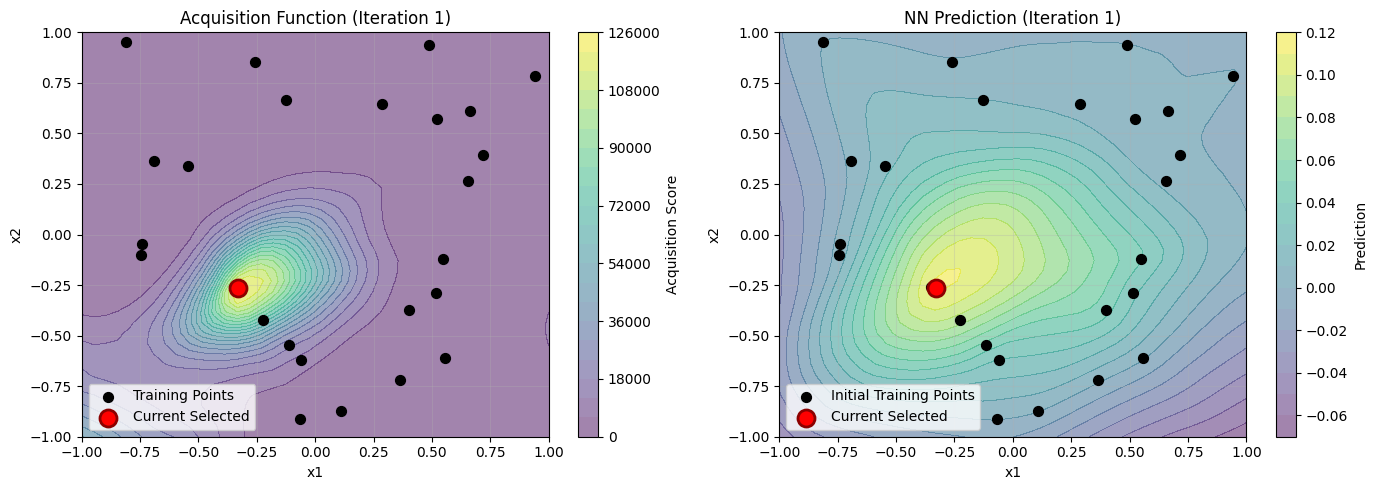

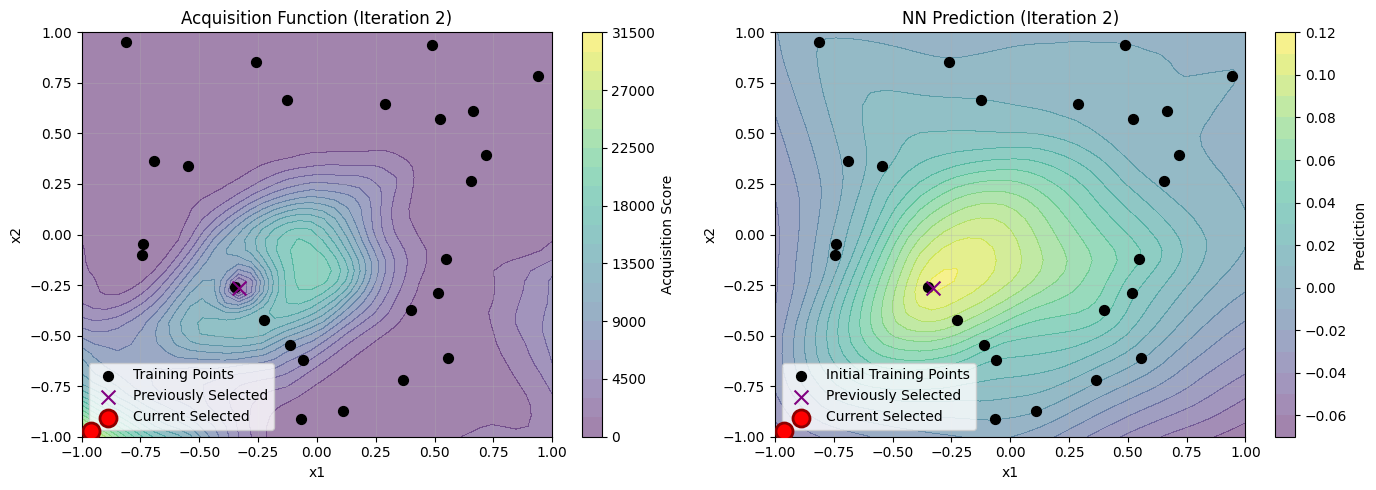

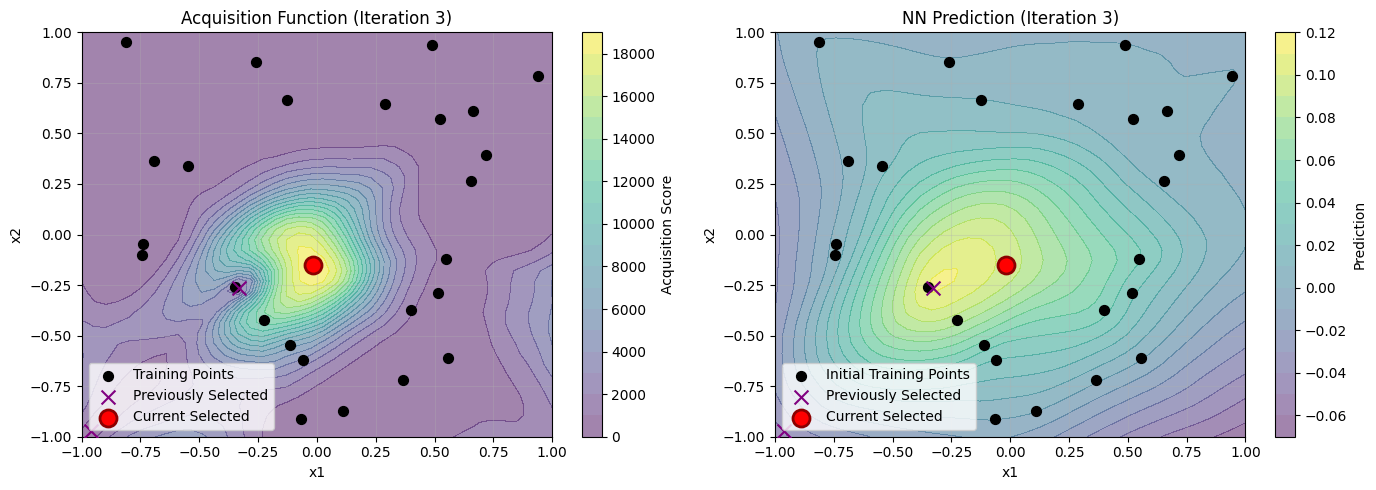

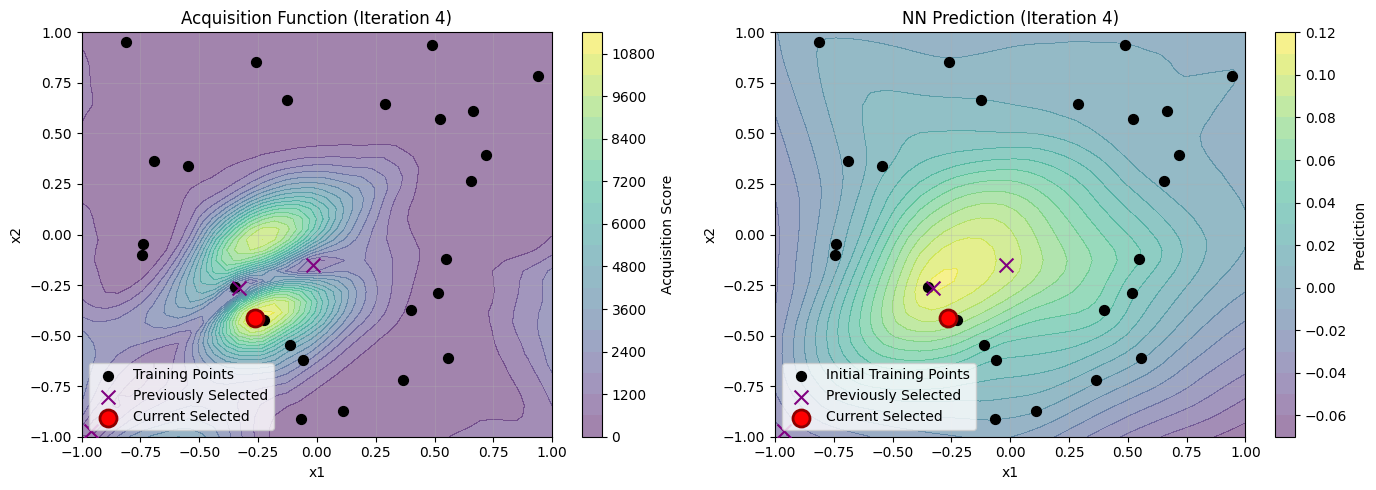

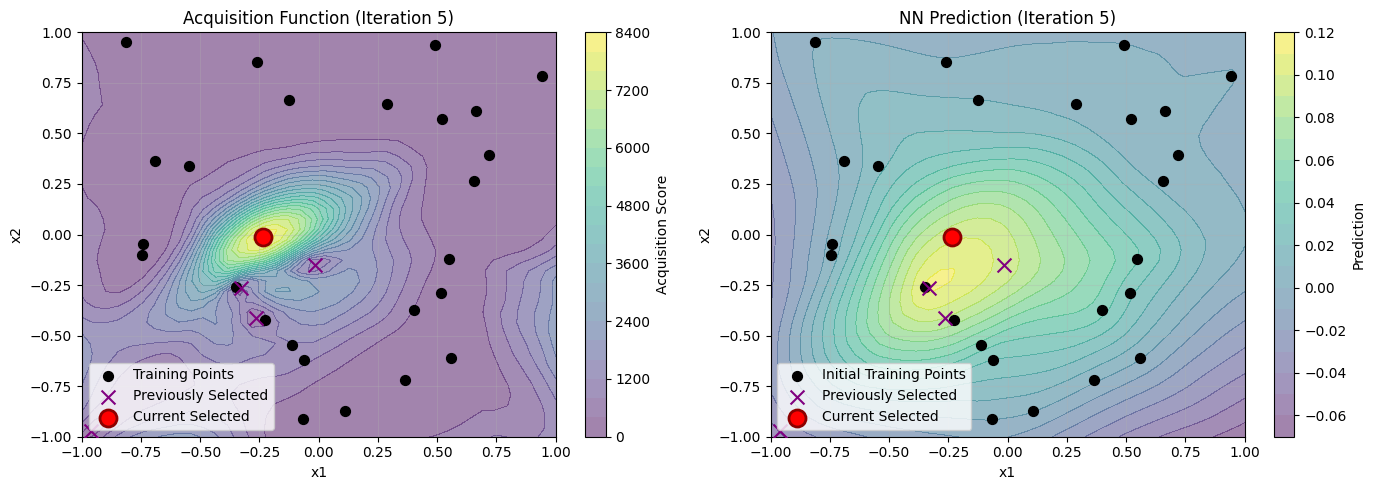

In [10]:
def plot_iteration_2d(iteration_data, sampler, all_selected_points, iteration_idx):
    """Plot acquisition function and NN prediction for a single 2D iteration."""
    data = iteration_data[iteration_idx]
    X1_orig = data['X1_orig']
    X2_orig = data['X2_orig']
    grid_points = data['grid_points']  # In original unscaled space
    acq_values = data['acq_values']
    selected_point = data['selected_point']  # In original unscaled space
    bounds = sampler.bounds
    
    regressor = sampler.regressor
    train_X = sampler.initial_inputs  # In original unscaled space
    train_y = sampler.initial_targets
    
    # Reshape acquisition values for contour plot
    acq_grid = np.array(acq_values).reshape(X1_orig.shape)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Acquisition Function Plot (Left)
    cs1 = axs[0].contourf(X1_orig, X2_orig, acq_grid, cmap='viridis', levels=20, alpha=0.5)
    
    # Plot training points
    axs[0].scatter(train_X[:, 0], train_X[:, 1], color='black', marker='o', s=50, label="Training Points", edgecolor='k', zorder=4)
    
    # Plot previously selected points
    if iteration_idx > 0:
        prev_points = all_selected_points[:iteration_idx]
        axs[0].scatter(prev_points[:, 0], prev_points[:, 1], color='purple', marker='x', s=100, label='Previously Selected', zorder=5)
    
    # Plot current selected point
    axs[0].scatter([selected_point[0]], [selected_point[1]], color='red', s=150, label='Current Selected', zorder=6, edgecolor='darkred', linewidth=2)
    
    axs[0].set_title(f"Acquisition Function (Iteration {iteration_idx + 1})")
    axs[0].set_xlabel("x1")
    axs[0].set_ylabel("x2")
    plt.colorbar(cs1, ax=axs[0], label="Acquisition Score")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)
    
    # NN Prediction Plot (Right)
    # Scale grid_points for prediction
    grid_points_scaled = sampler.input_scaler.transform(grid_points)
    preds = regressor.predict(torch.tensor(grid_points_scaled, dtype=torch.float32))
    mean_preds = sampler.output_scaler.inverse_transform(preds[0].reshape(-1, 1)).flatten()
    
    # Reshape for contour plot
    pred_grid = mean_preds.reshape(X1_orig.shape)
    
    cs2 = axs[1].contourf(X1_orig, X2_orig, pred_grid, cmap='viridis', levels=20, alpha=0.5)
    
    # Plot training points
    axs[1].scatter(train_X[:, 0], train_X[:, 1], color='black', marker='o', s=50, label="Initial Training Points", edgecolor='k', zorder=4)
    
    # Plot previously selected points
    if iteration_idx > 0:
        prev_points = all_selected_points[:iteration_idx]
        axs[1].scatter(prev_points[:, 0], prev_points[:, 1], color='purple', marker='x', s=100, label='Previously Selected', zorder=5)
    
    # Plot current selected point
    axs[1].scatter([selected_point[0]], [selected_point[1]], color='red', s=150, label='Current Selected', zorder=6, edgecolor='darkred', linewidth=2)
    
    axs[1].set_title(f"NN Prediction (Iteration {iteration_idx + 1})")
    axs[1].set_xlabel("x1")
    axs[1].set_ylabel("x2")
    plt.colorbar(cs2, ax=axs[1], label="Prediction")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create plots for each iteration
print(f"Creating plots for {len(iteration_data_2d)} iterations...\n")
for i in range(len(iteration_data_2d)):
    plot_iteration_2d(iteration_data_2d, badge_sampler_2d_tracking, selected_points_2d_tracked, i)

# RMSE Comparison Across Sampling Methods

This section compares the RMSE performance of different sampling strategies: GRUBS, UNC, DIV, random sampling, and sequential uncertainty sampling (GRUBS with batch size 1). We start with 25 initial points and add 5 batches of 5 points each (except for sequential which adds 1 point at a time). Results are averaged over multiple trials with standard deviations shown.

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
from UBAS.samplers.grubs_sampler import GRUBSSampler
from UBAS.samplers.base_sampler import BaseSampler
from UBAS.generators.central_peak_generator import CentralPeakGenerator
from UBAS.generators.input_generator import InputGenerator
from uqregressors.bayesian.deep_ens import DeepEnsembleRegressor
from uqregressors.metrics.metrics import compute_all_metrics

# Parameters for comparison
num_trials = 5
initial_points = 25
batches = 3
batch_size = 5
sequential_batch_size = 1
bounds_2d = np.array([[-1, -1], [1, 1]])
bounds_2d_test = np.array([[-0.25, -0.25], [0.25, 0.25]])
ndim = 2

# Generate test set for RMSE calculation
generator = CentralPeakGenerator()
input_sampler_test = InputGenerator(bounds_2d_test, ndim, seed=123)
test_inputs, test_targets = generator.generate(input_sampler_test.uniformly_sample(1000))

print(f"Test set size: {len(test_inputs)}")

# Methods to compare
methods = ['GRUBS', 'UNC', 'DIV', 'random', 'sequential']

# Store RMSE results: methods with x and rmse arrays
rmse_results = {method: {'x': [], 'rmse': None} for method in methods}

print(f"Methods: {methods}")

Test set size: 1000
Methods: ['GRUBS', 'UNC', 'DIV', 'random', 'sequential']


Running trials for GRUBS...


d:\UQ_benchmarking\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

d:\UQ_benchmarking\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Evaluating Model:

d:\UQ_benchmarking\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Selecting point: 1/1

Selected point 1: [0.81071335 0.42798436]

Saving Sampler: Overriding previous state

d:\UQ_benchmarking\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Re-training regressor on full training data: 
Evaluating regressor: 
Saving data: 
Sampling has finished successfully
  Trial 5/5 completed
All trials completed!


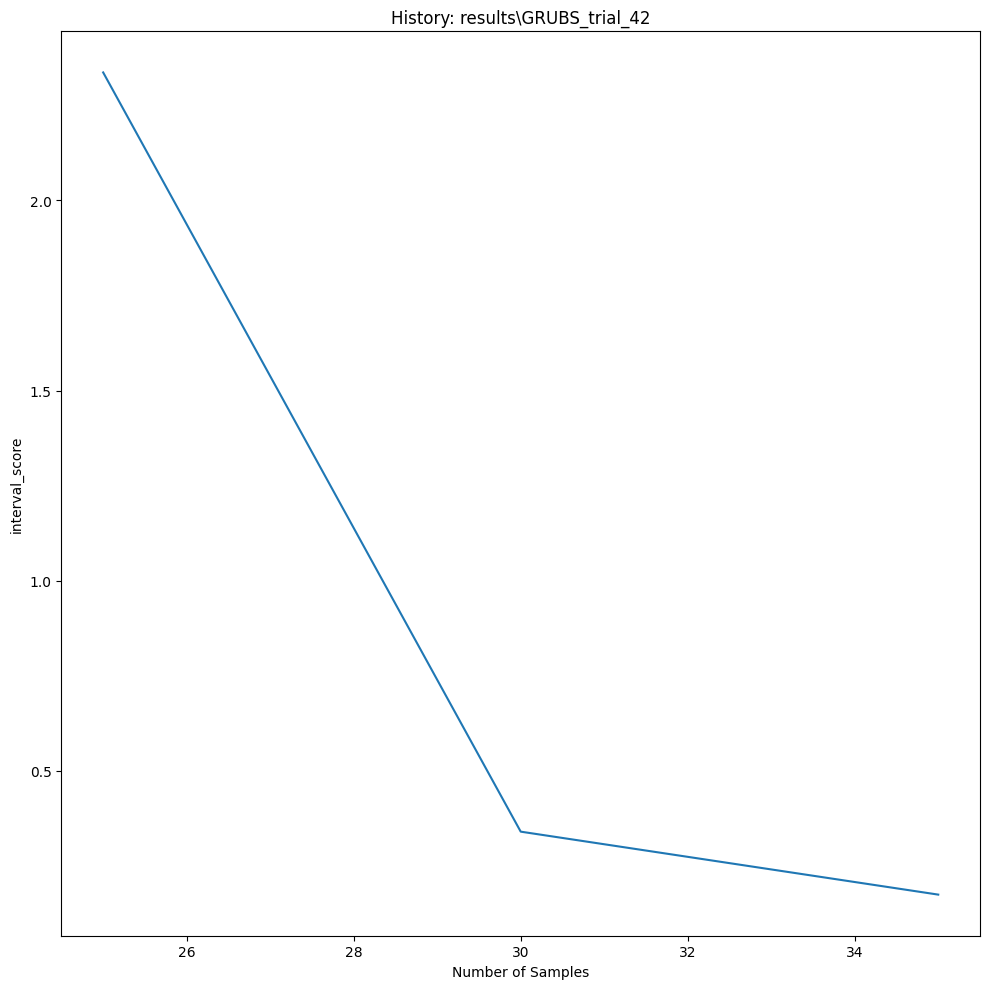

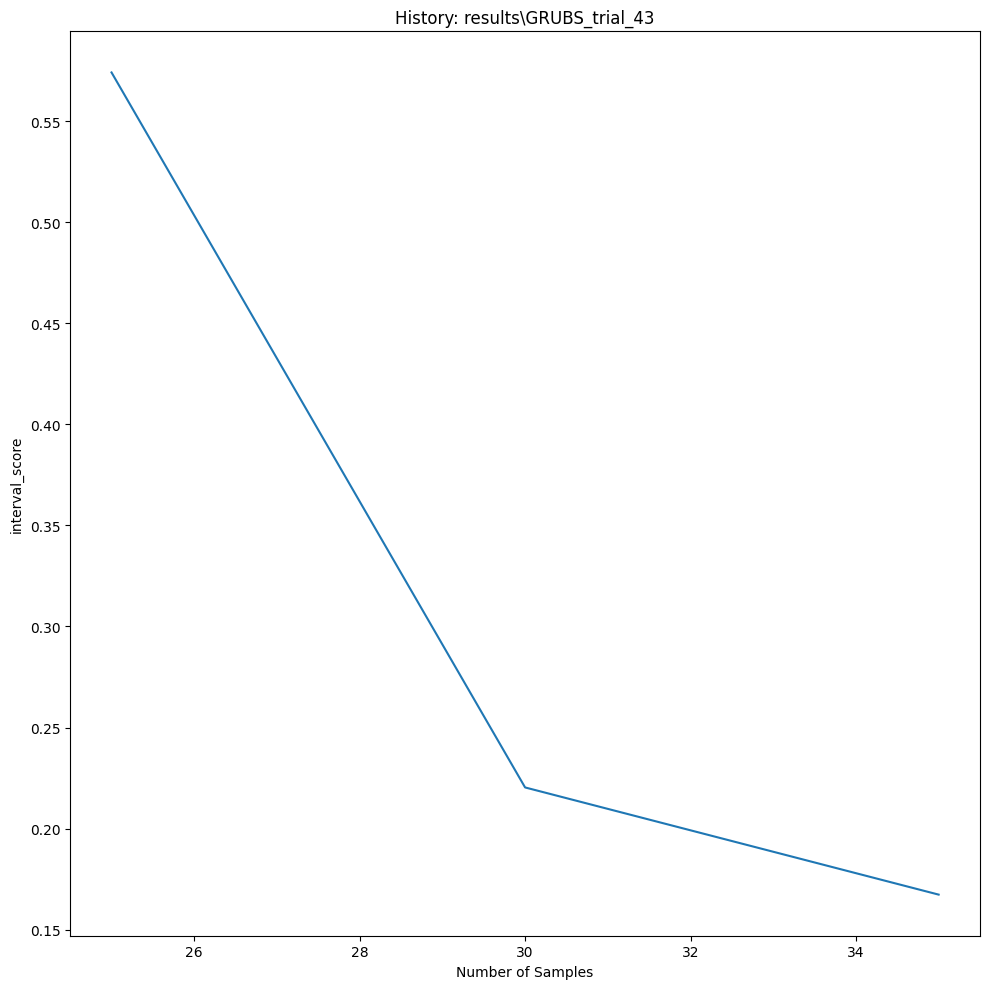

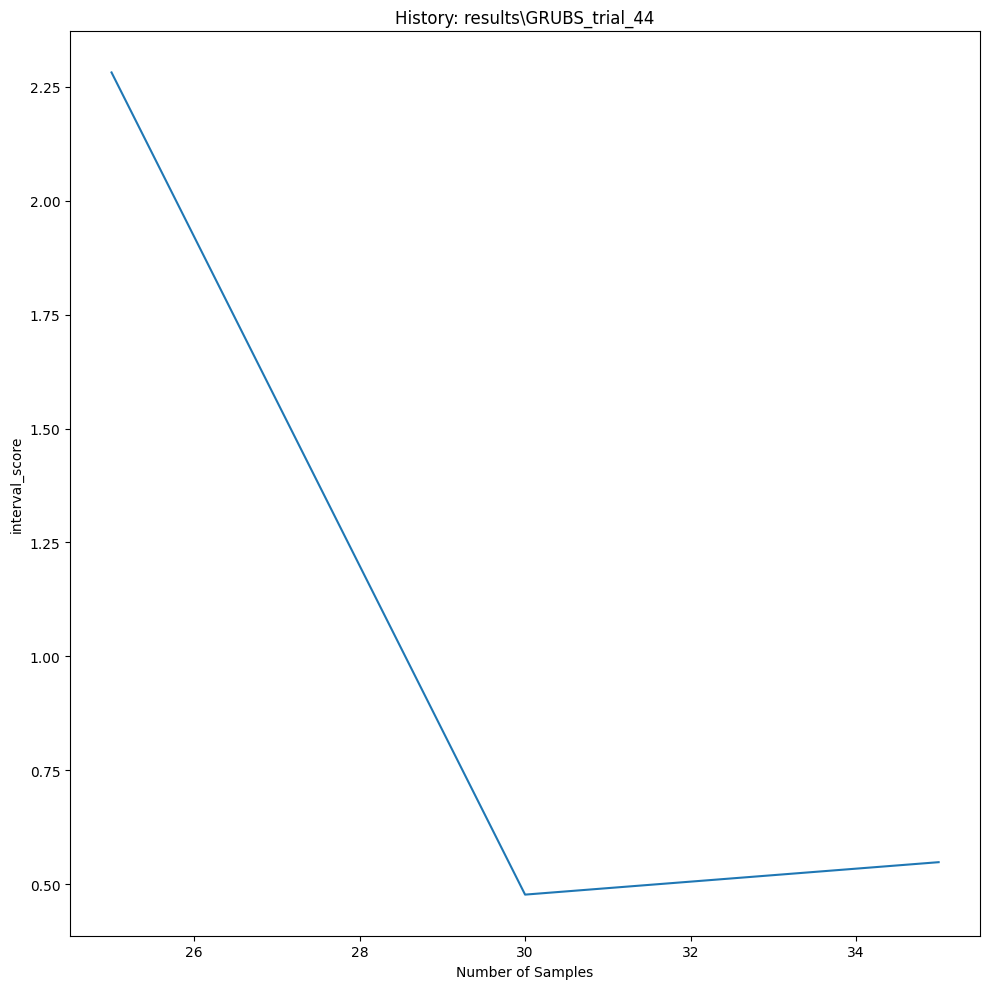

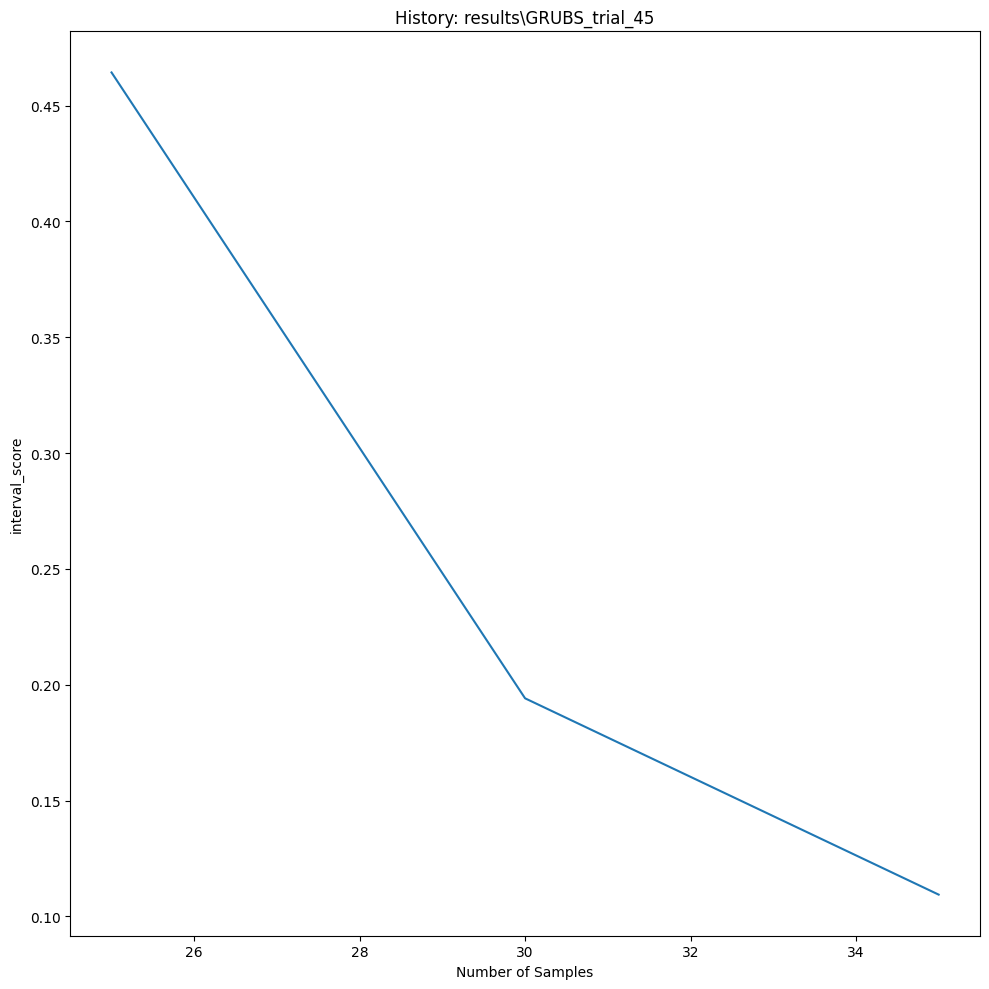

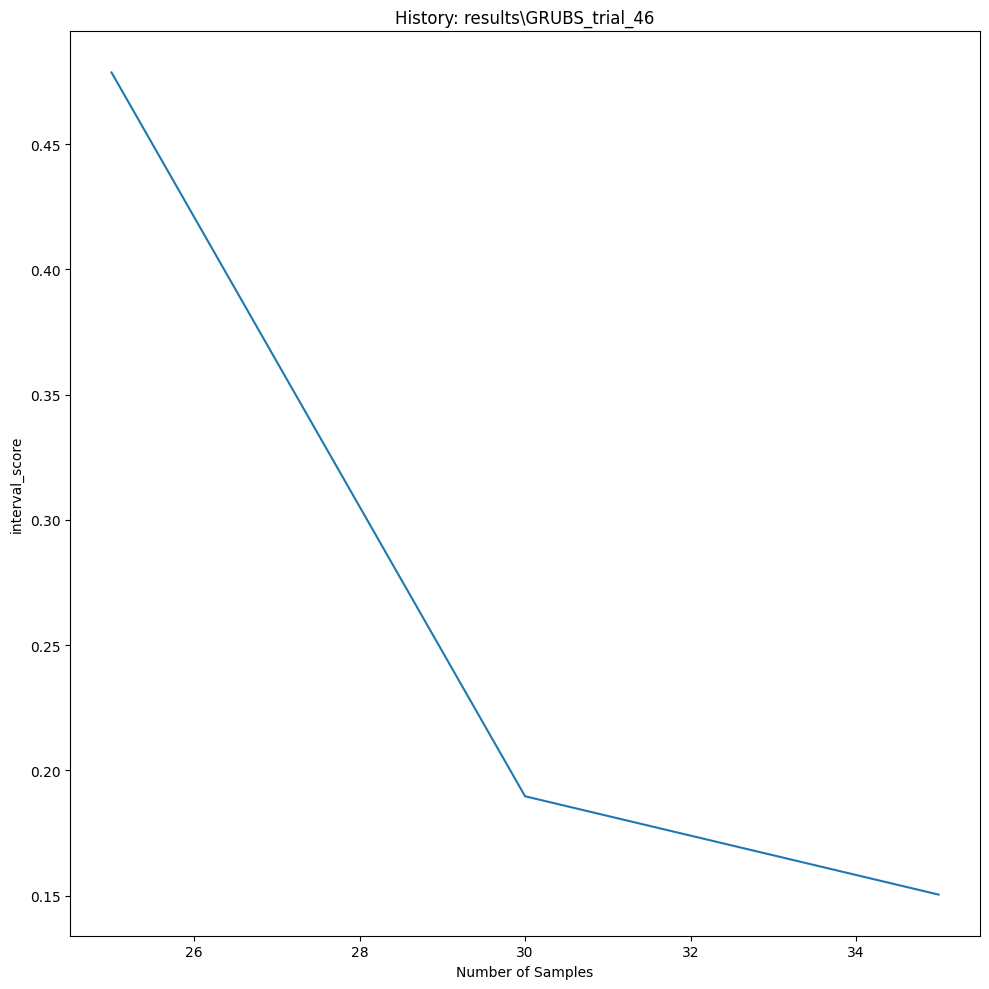

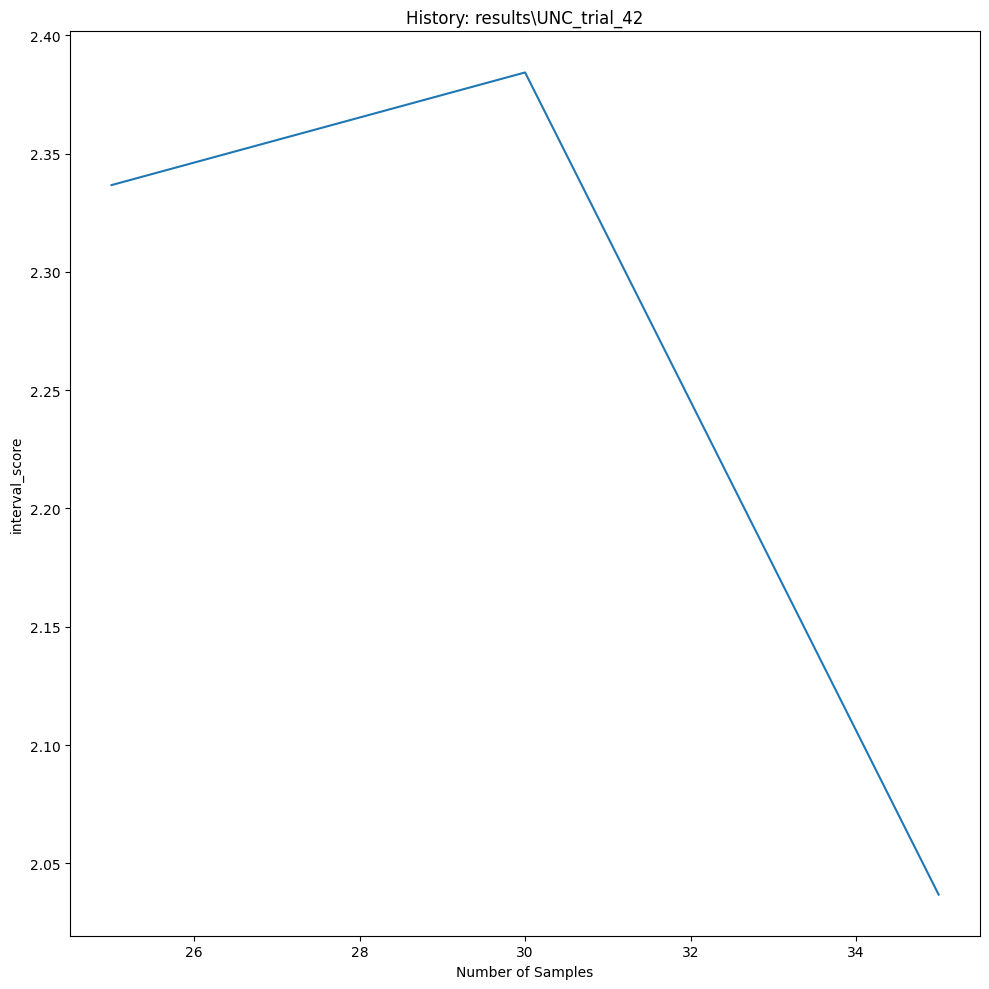

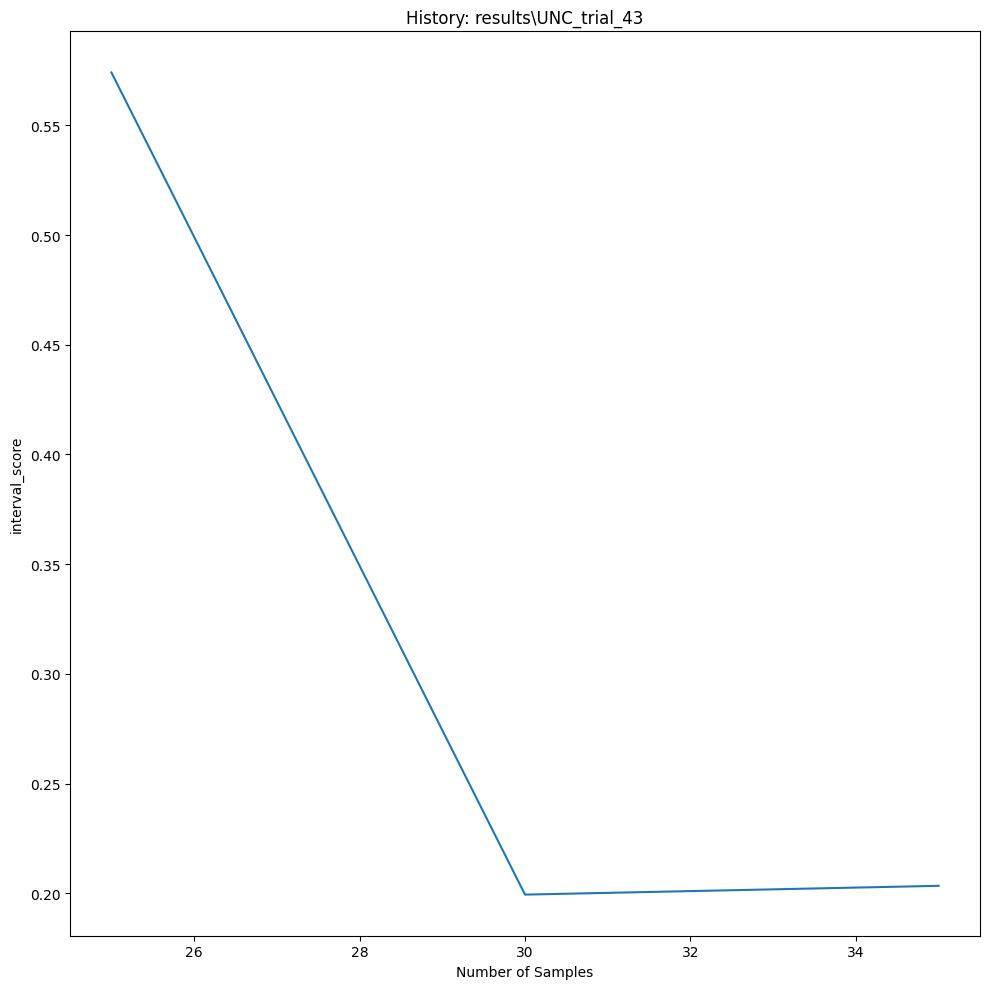

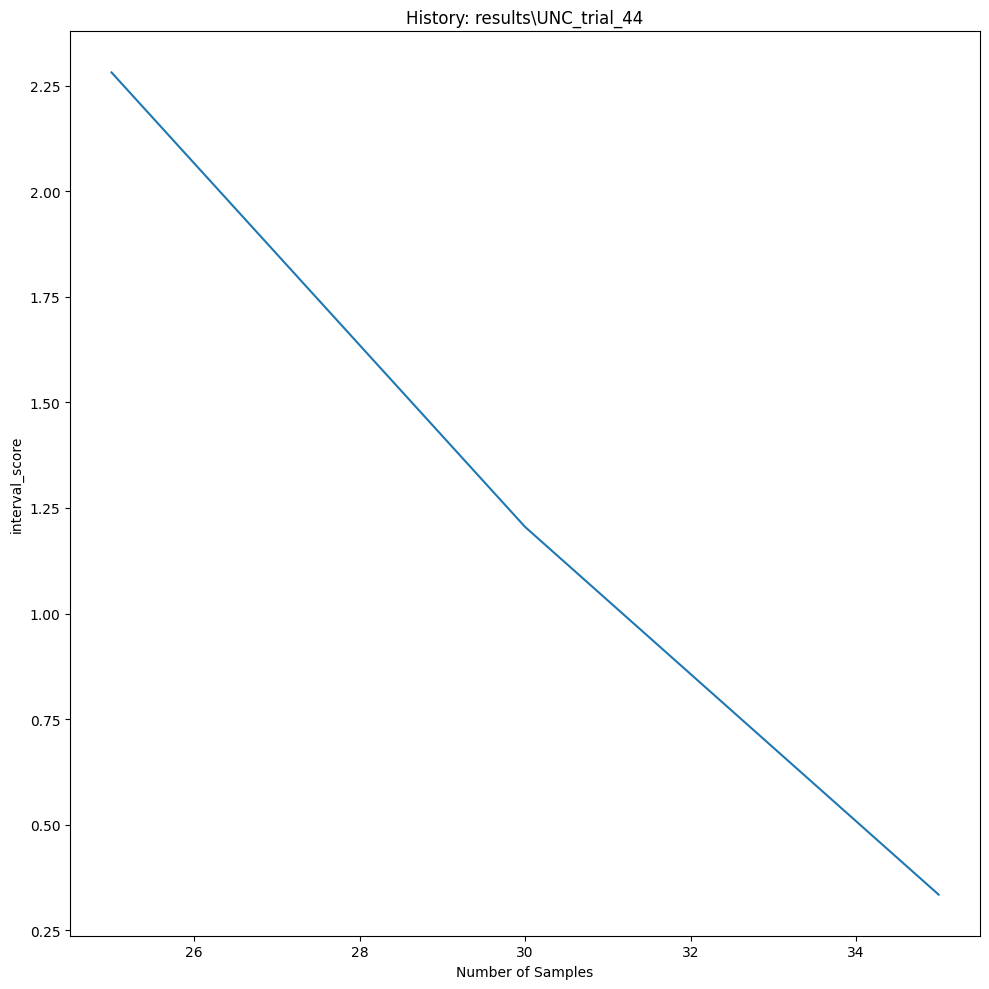

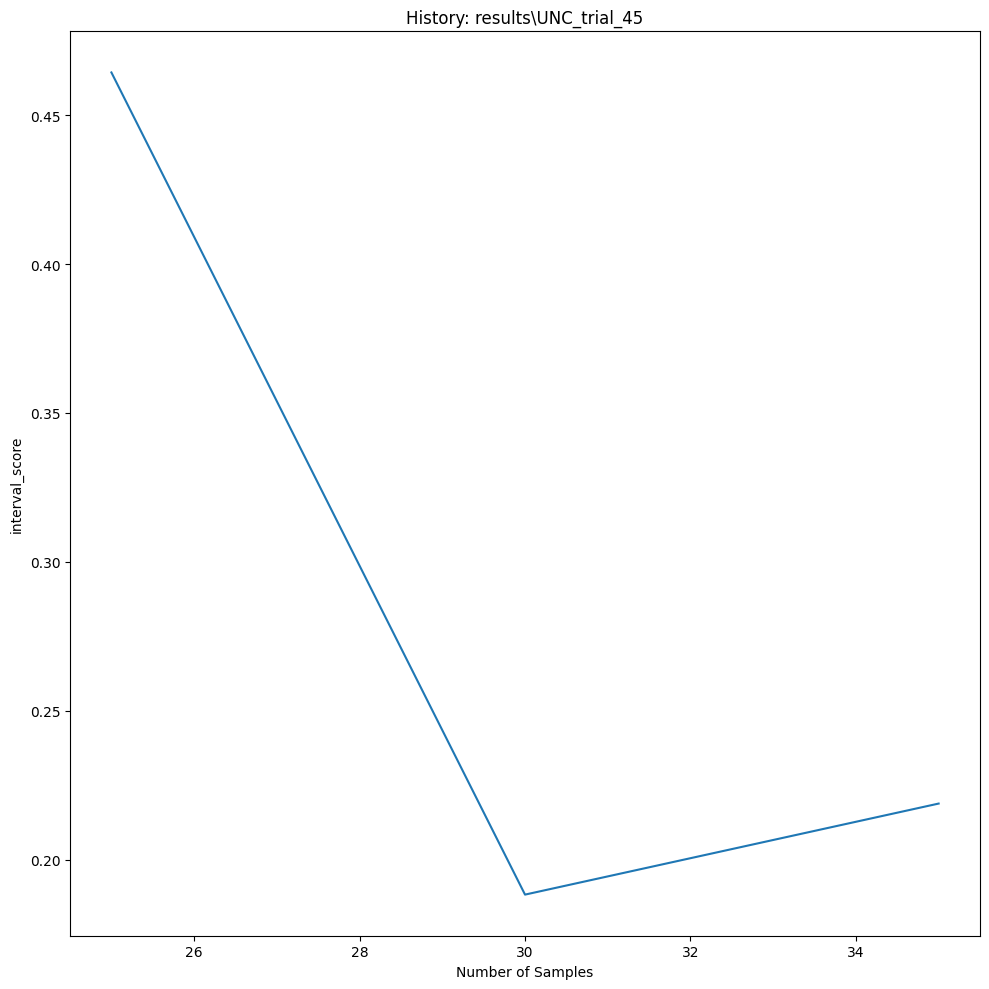

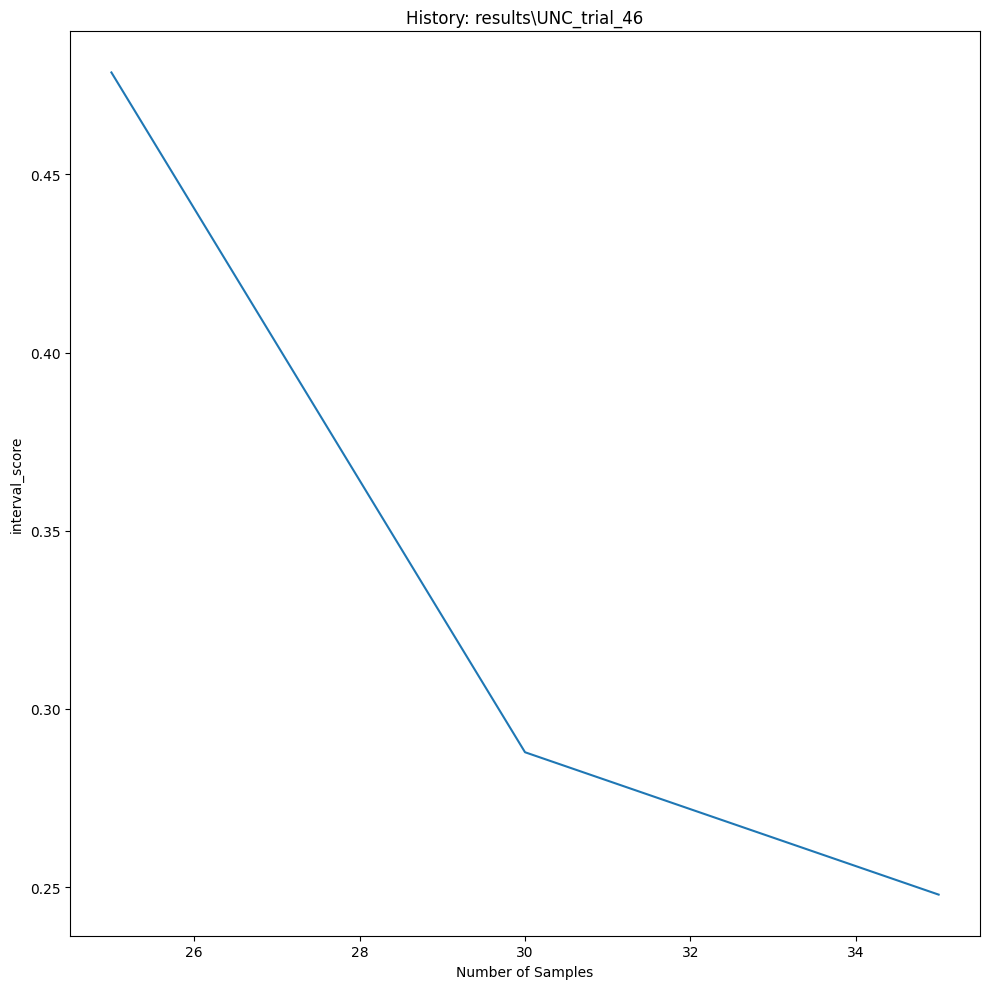

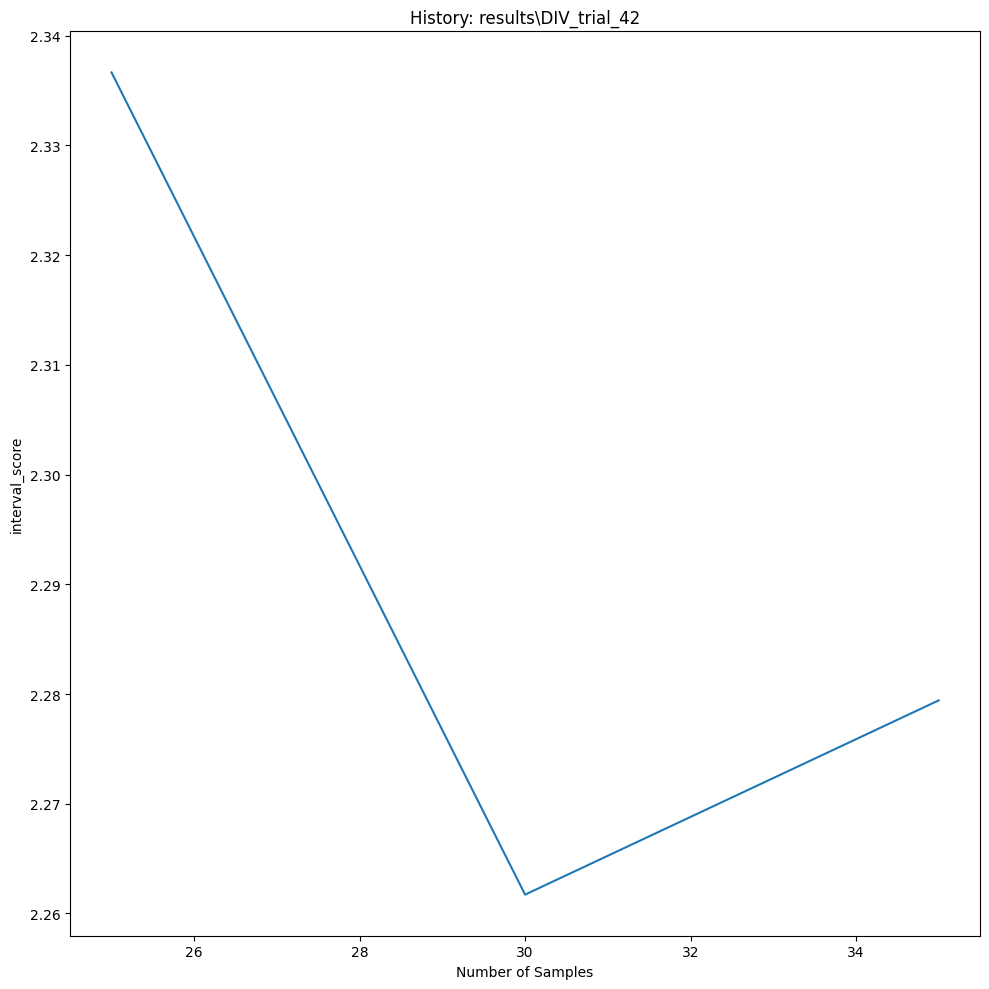

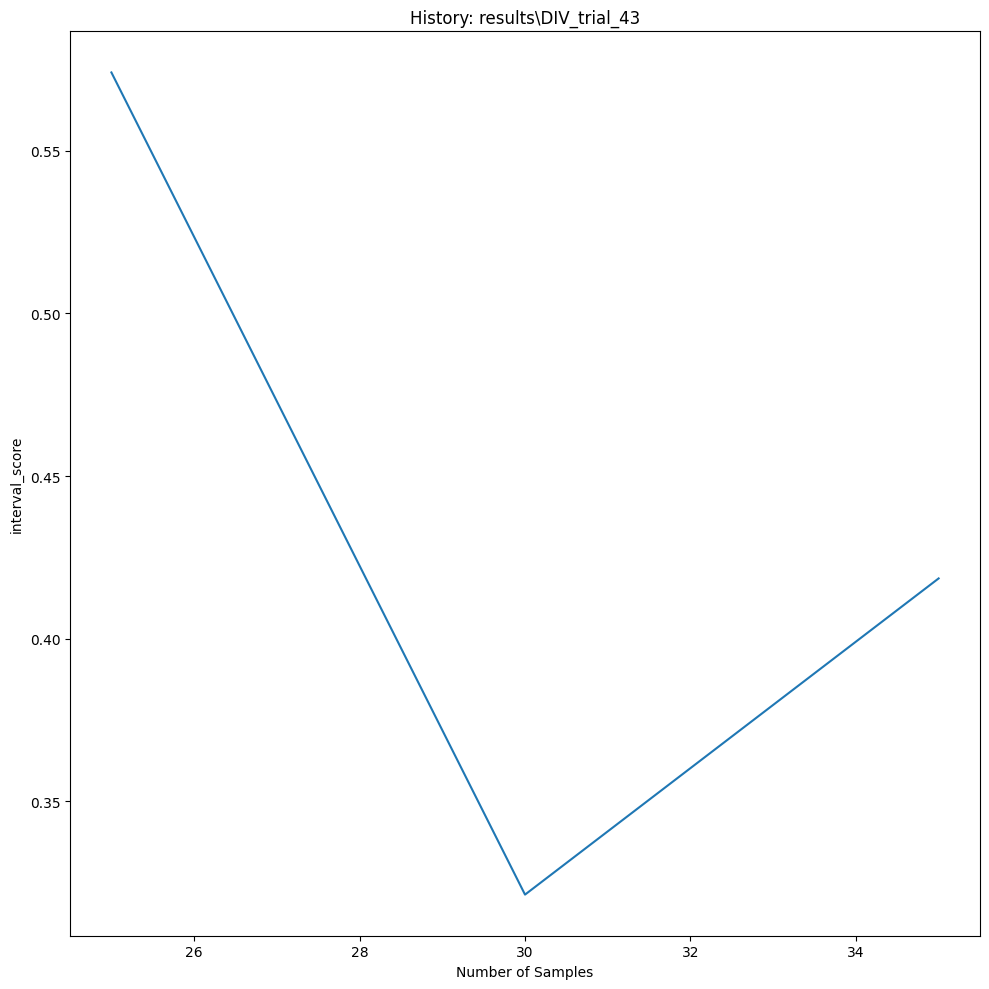

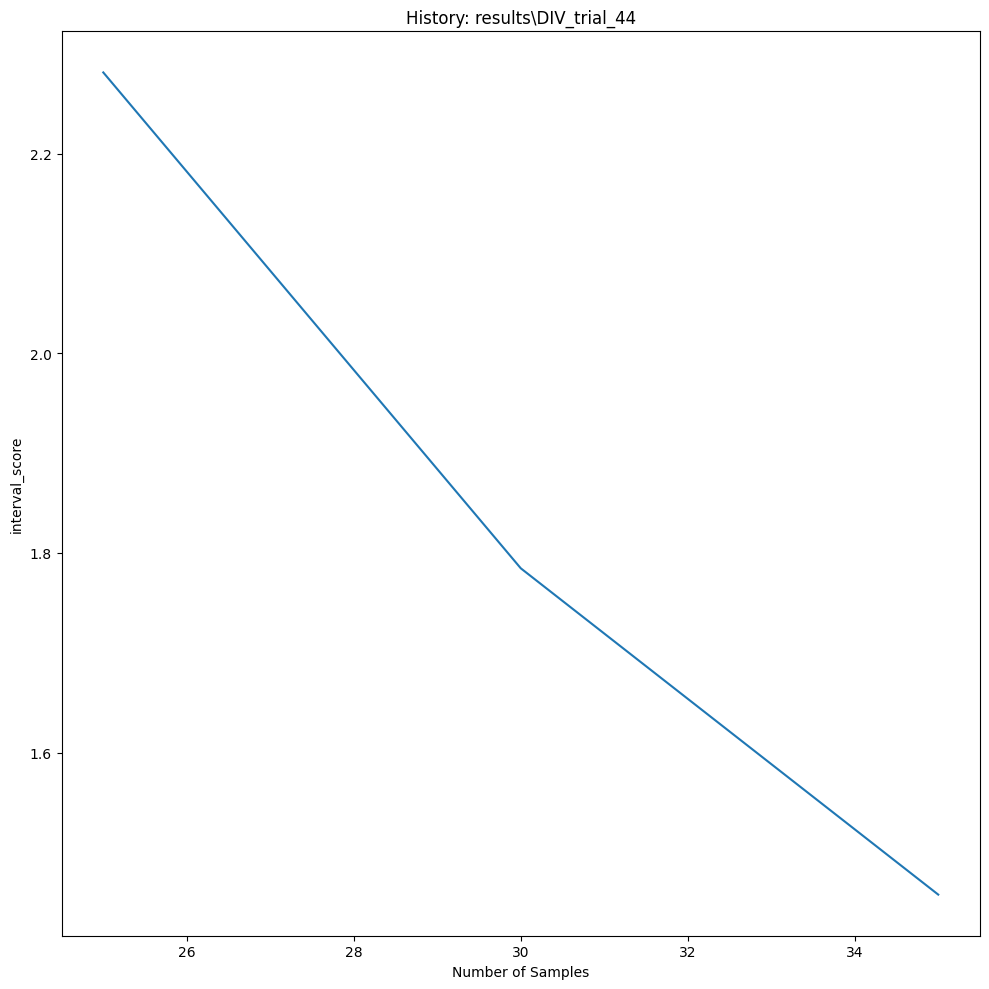

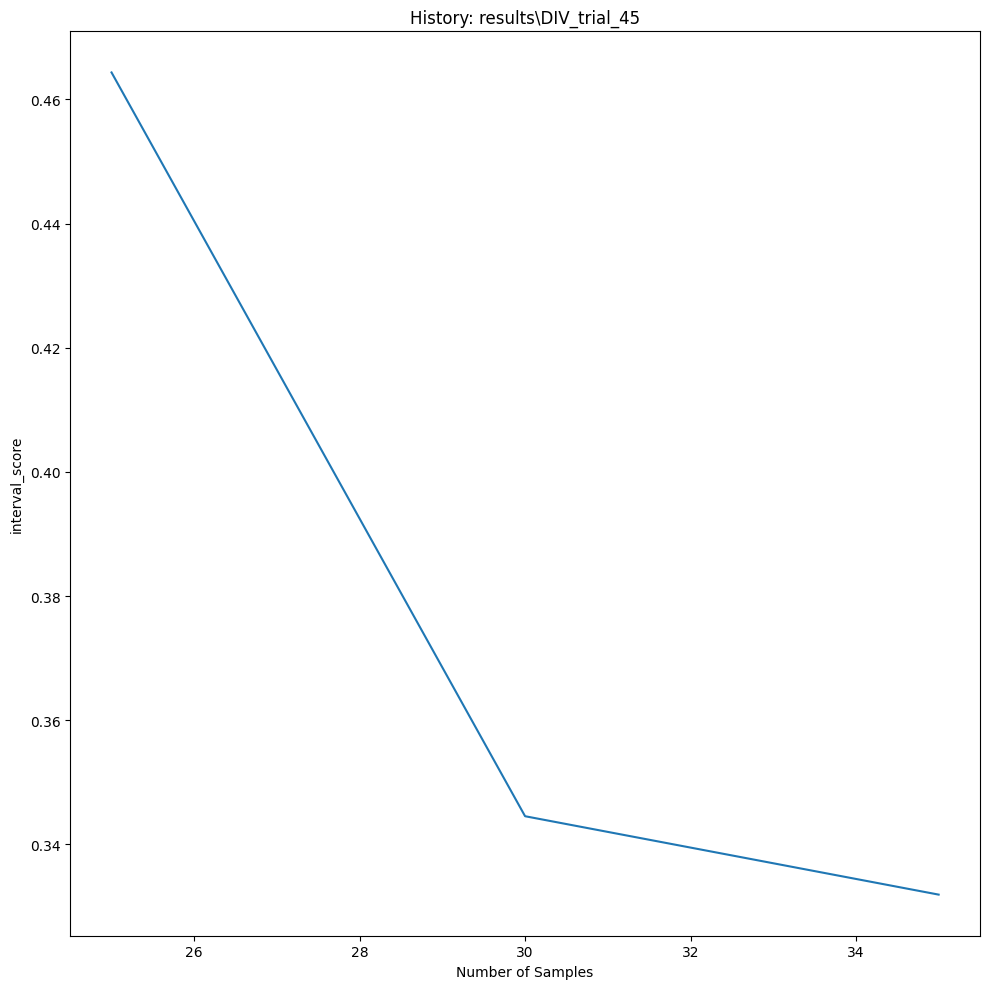

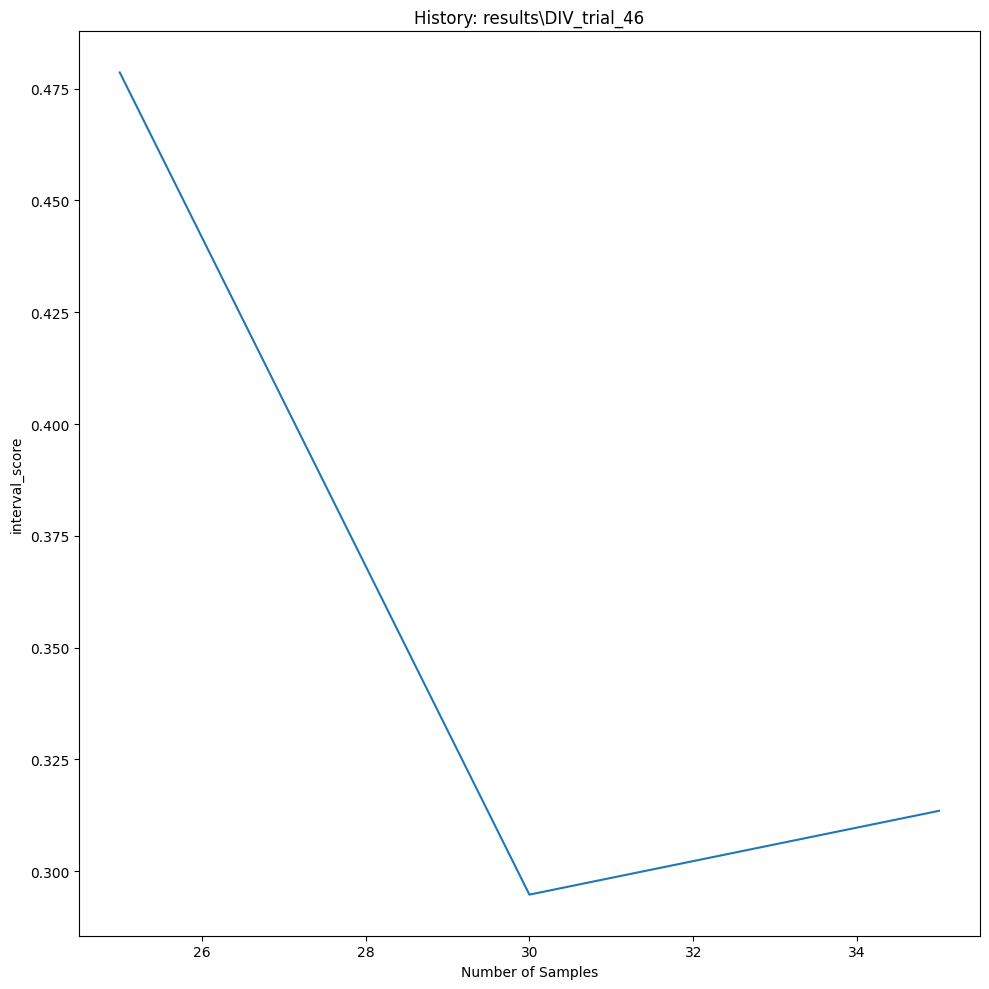

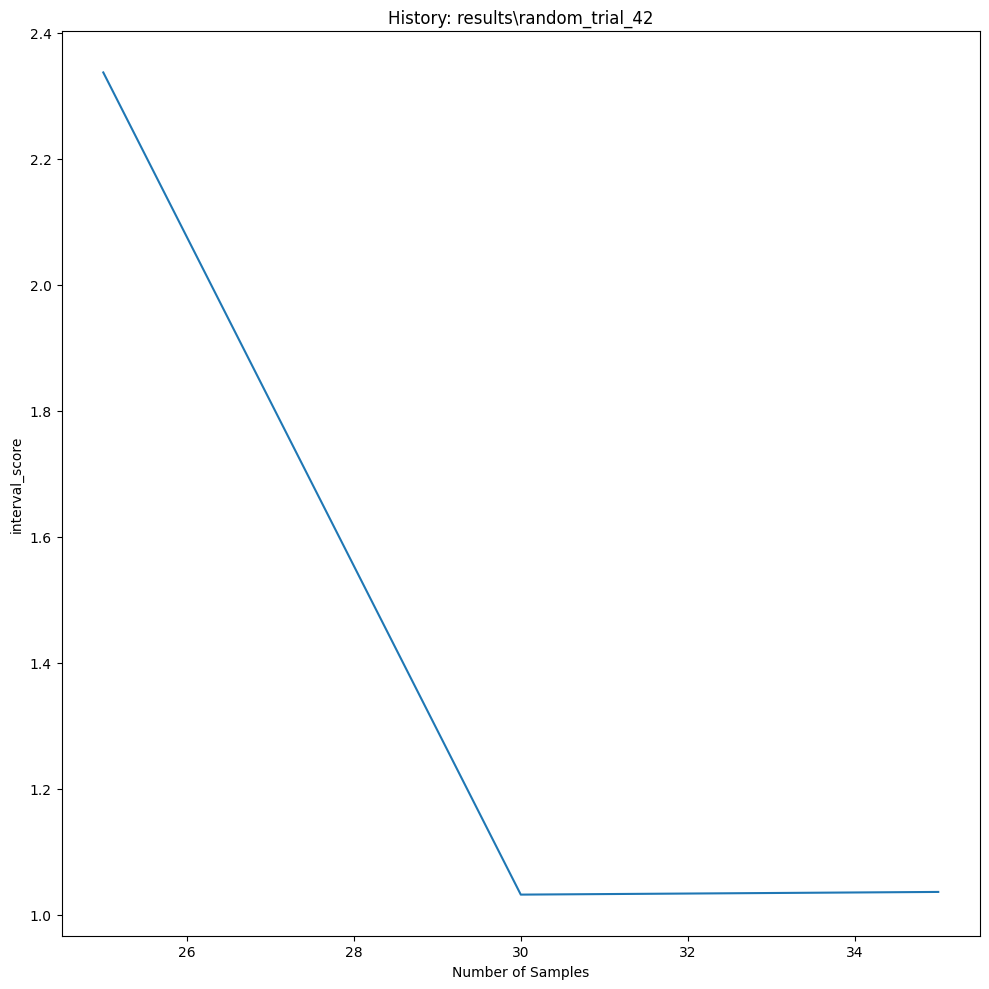

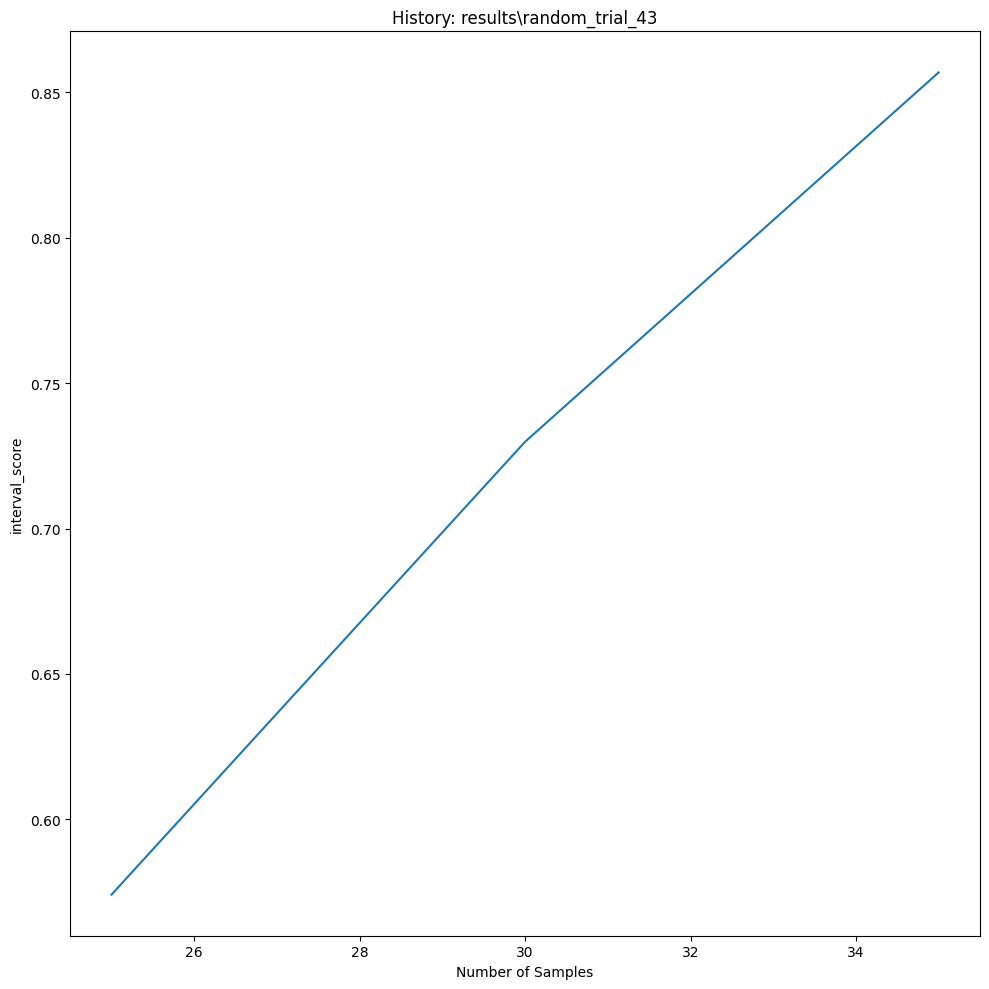

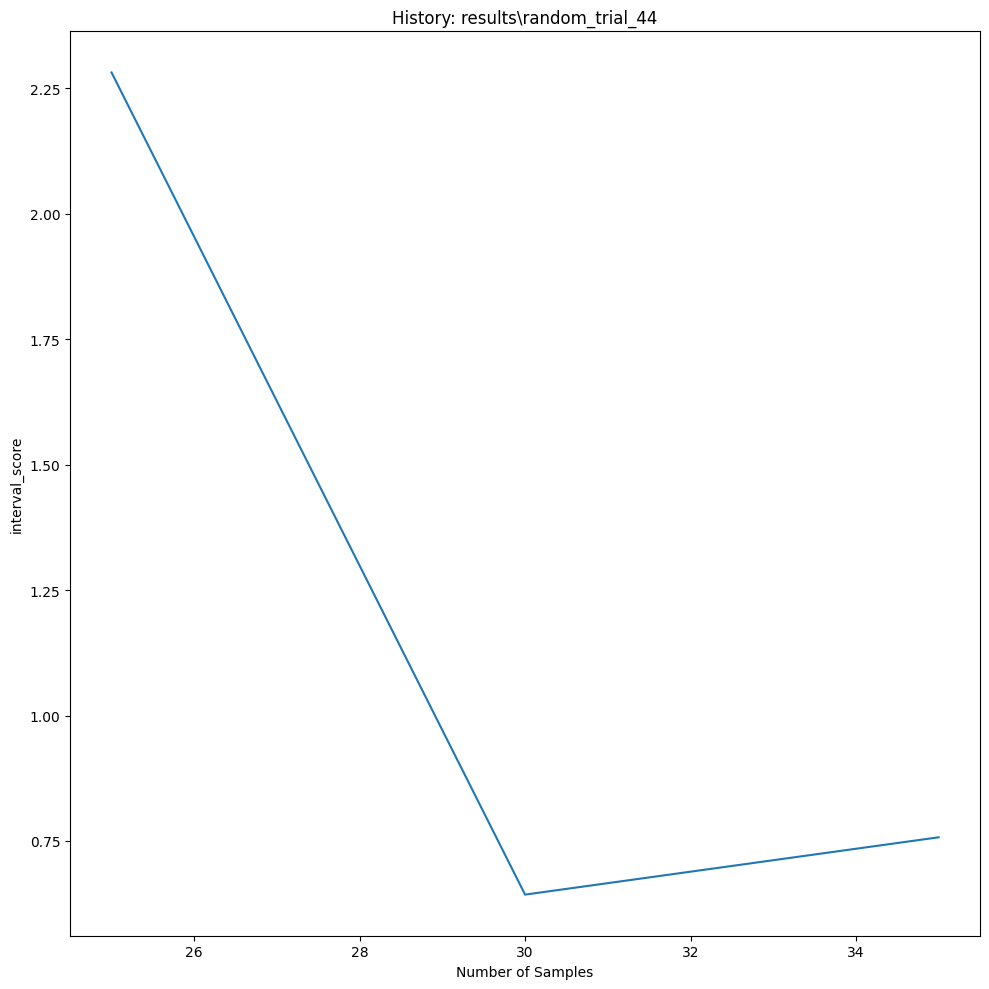

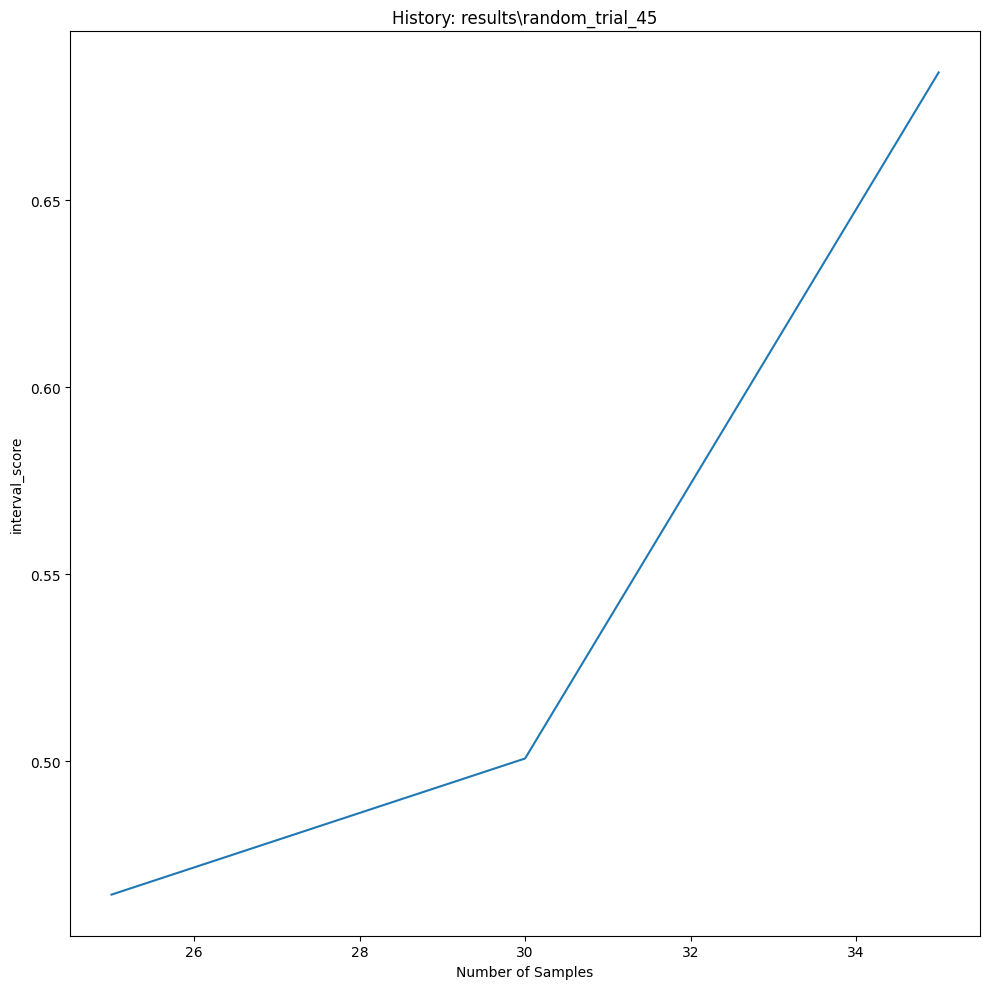

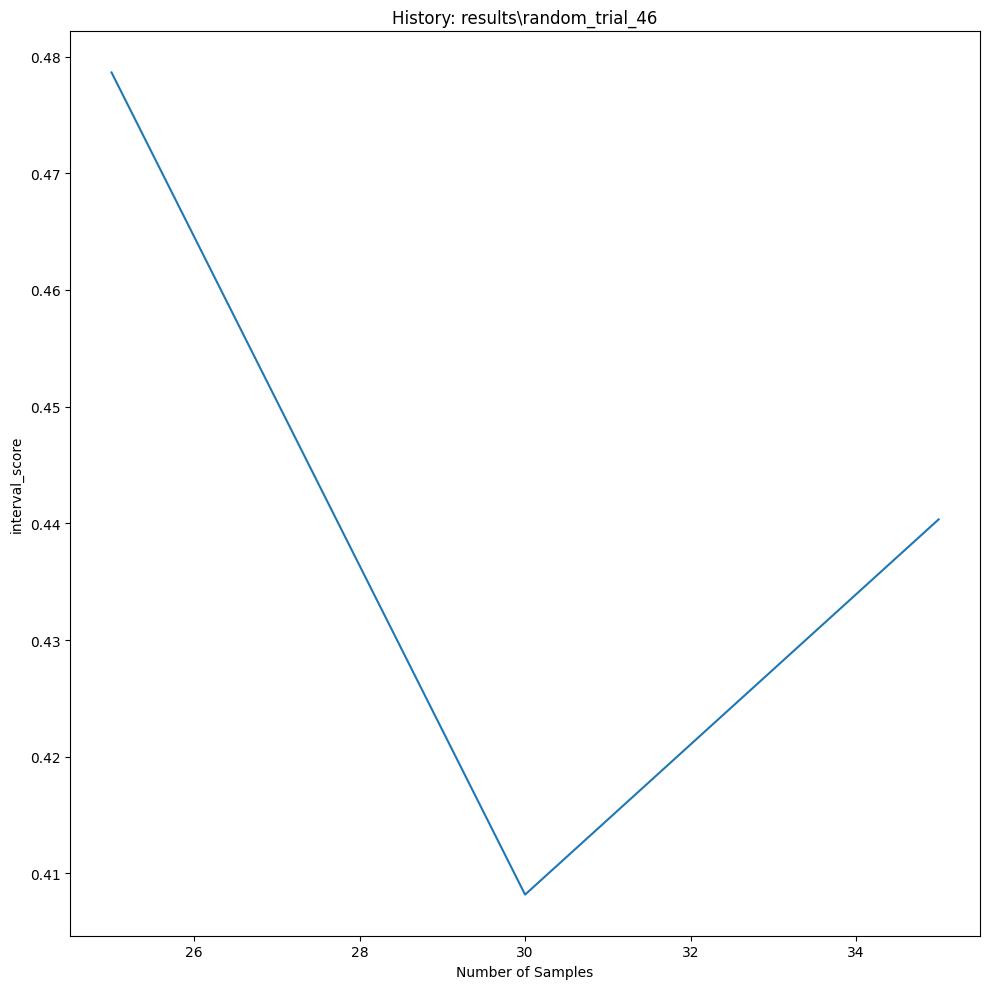

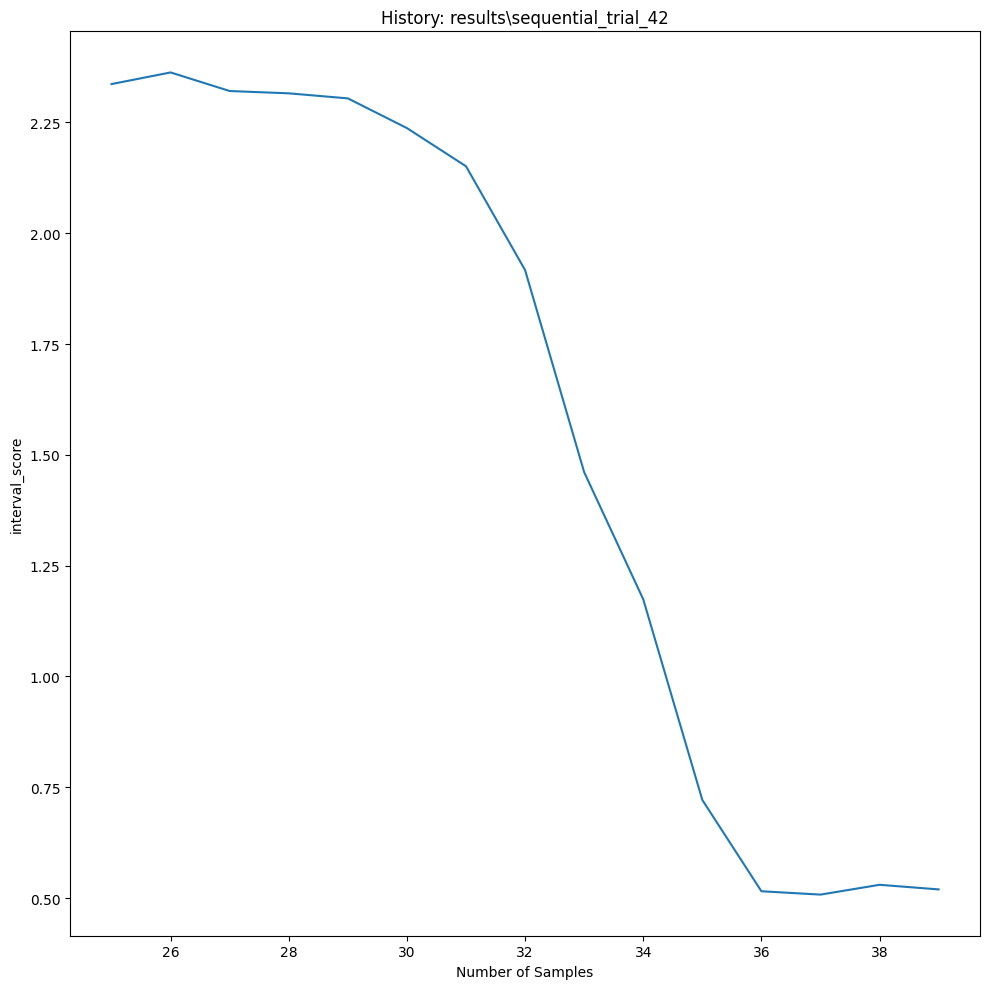

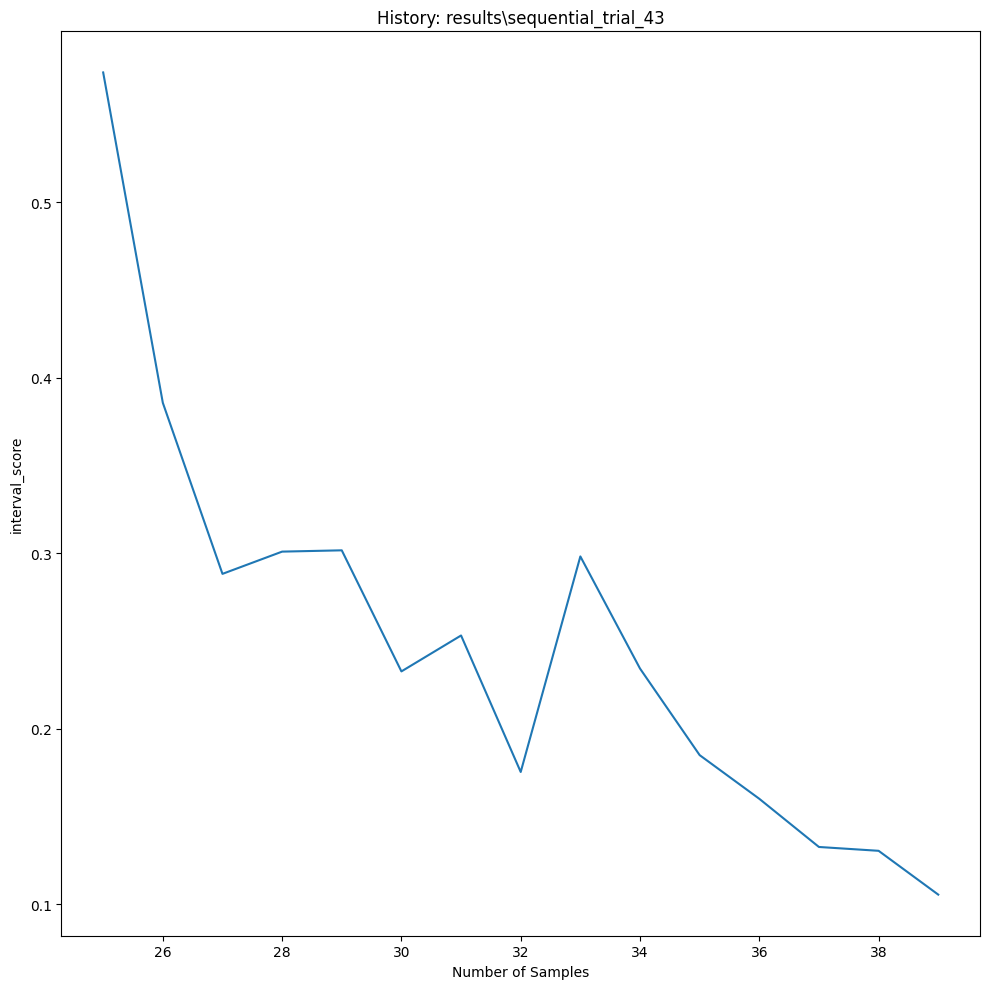

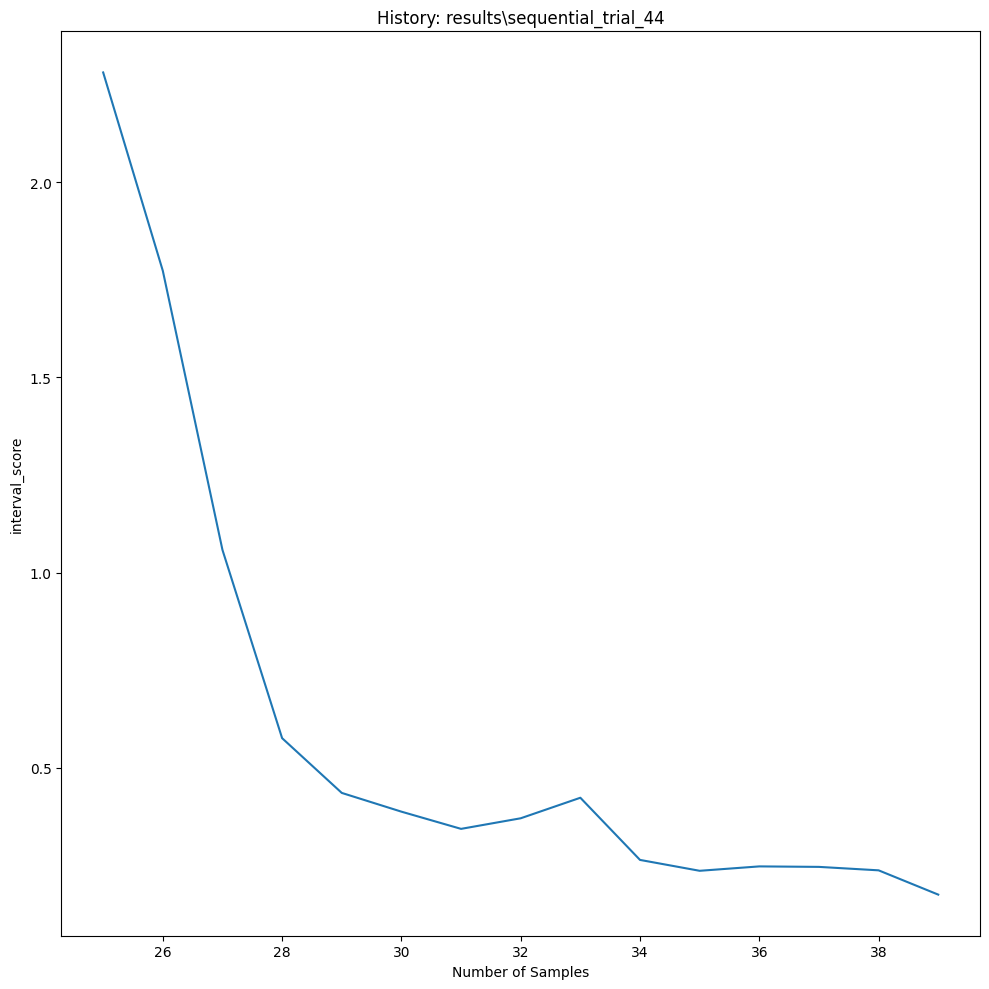

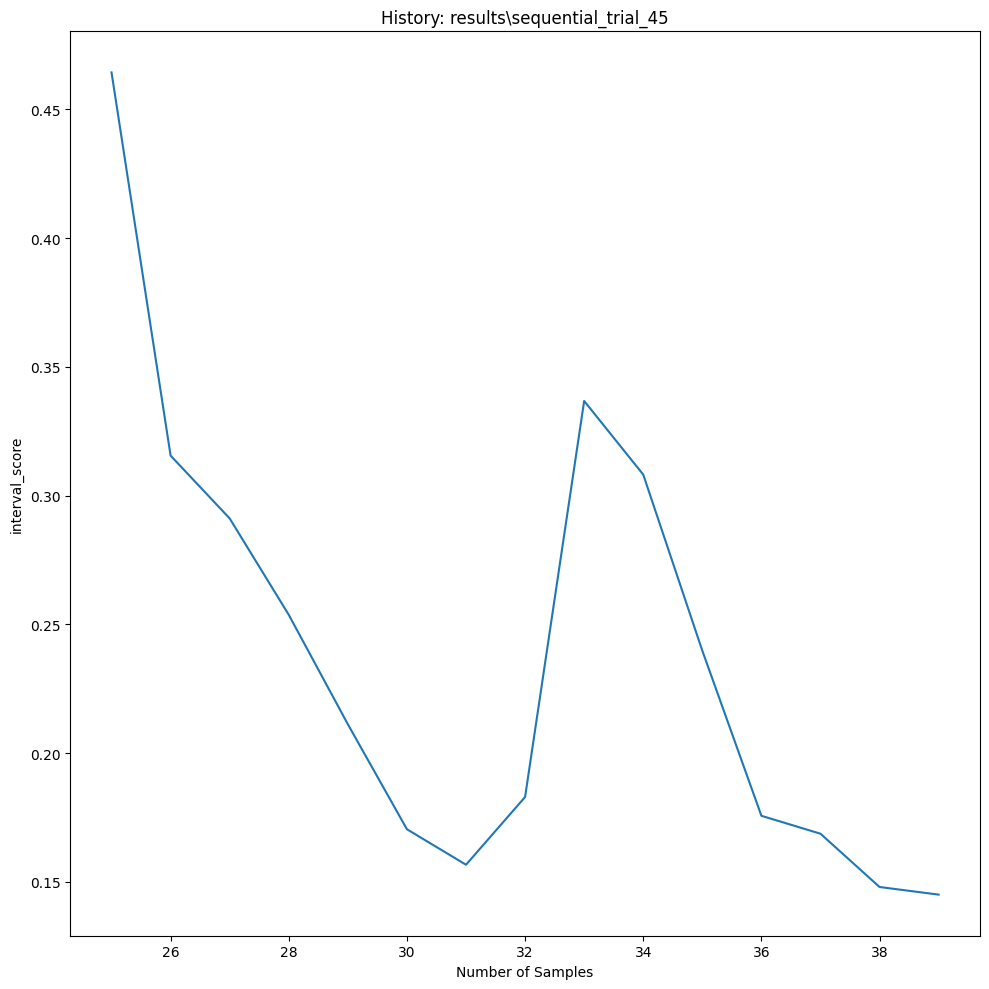

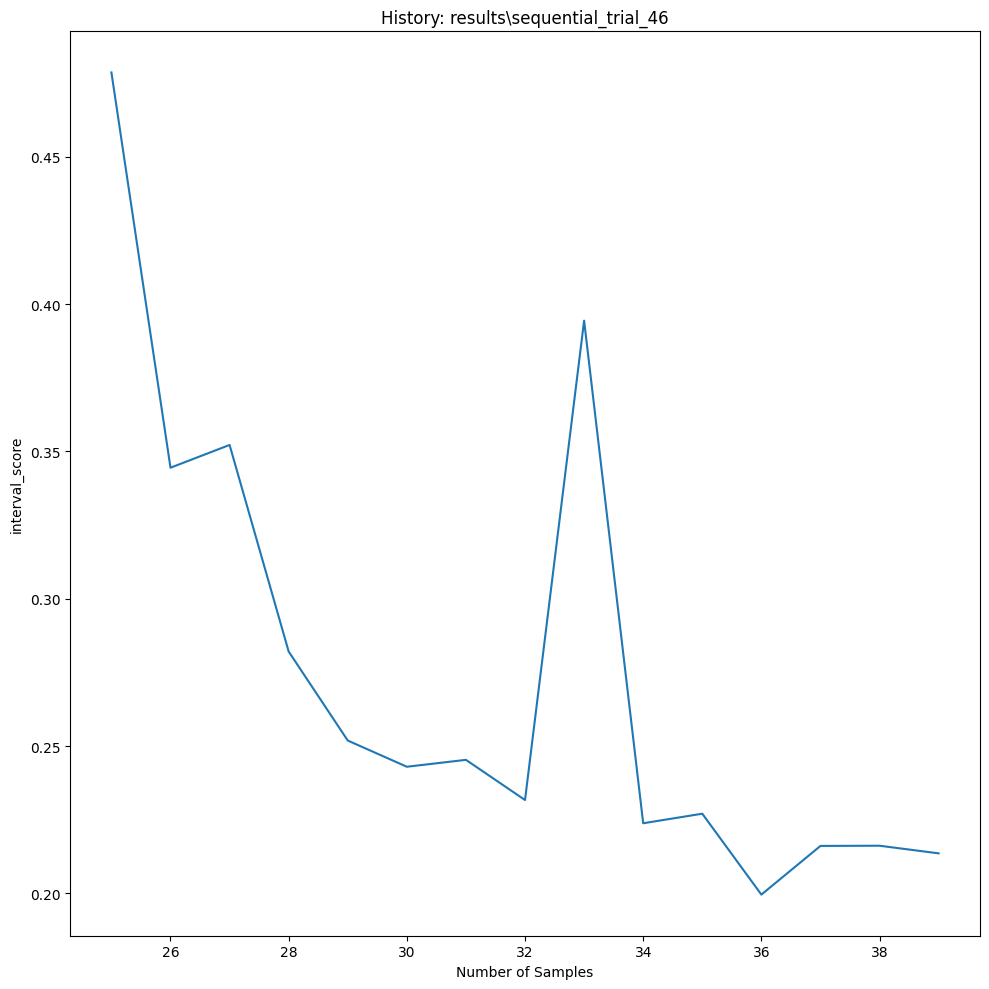

In [8]:
def run_trial(method, trial_seed):
    """Run a single trial for a given method and return RMSE at each training size."""
    np.random.seed(trial_seed)
    torch.manual_seed(trial_seed)
    
    # Generate initial training data
    input_sampler = InputGenerator(bounds_2d, ndim, seed=trial_seed)
    train_inputs, train_targets = generator.generate(input_sampler.uniformly_sample(initial_points))
    
    # Initialize regressor
    regressor = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[100, 100], epochs=500, learning_rate=0.001, batch_size=32, random_seed=trial_seed)
    
    if method == 'random':
        sampler = BaseSampler(
            directory=f"./results/{method}_trial_{trial_seed}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches,
            n_batch_points=batch_size,
            initial_inputs=train_inputs,
            initial_targets=train_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=trial_seed+1
        )
    elif method == 'sequential':
        sampler = GRUBSSampler(
            directory=f"./results/{method}_trial_{trial_seed}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches * batch_size,
            n_batch_points=sequential_batch_size,
            initial_inputs=train_inputs,
            initial_targets=train_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=trial_seed+1,
            n_initial_samples=1000,
            n_to_optimize=5,
            optimization_steps=10,
            opt_lr=0.001,
            mode='GRUBS'
        )
    else:
        sampler = GRUBSSampler(
            directory=f"./results/{method}_trial_{trial_seed}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches,
            n_batch_points=batch_size,
            initial_inputs=train_inputs,
            initial_targets=train_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=trial_seed+1,
            n_initial_samples=1000,
            n_to_optimize=5,
            optimization_steps=10,
            opt_lr=0.001,
            mode=method
        )
    
    # Run the sampling
    sampler.sample()
    
    # Extract RMSE history
    rmse_history = [perf['rmse'] for perf in sampler.model_performance if perf is not None]
    
    # Compute training sizes
    x = [initial_points + i * sampler.n_batch_points for i in range(len(rmse_history))]
    
    return {'x': x, 'rmse': np.array(rmse_history)}

# Run all trials
for method in methods:
    print(f"Running trials for {method}...")
    rmse_list = []
    for trial in range(num_trials):
        trial_seed = 42 + trial
        result = run_trial(method, trial_seed)
        rmse_list.append(result['rmse'])
        if trial == 0:  # Set x once
            rmse_results[method]['x'] = result['x']
        print(f"  Trial {trial+1}/{num_trials} completed")
    
    rmse_results[method]['rmse'] = np.array(rmse_list)

print("All trials completed!")

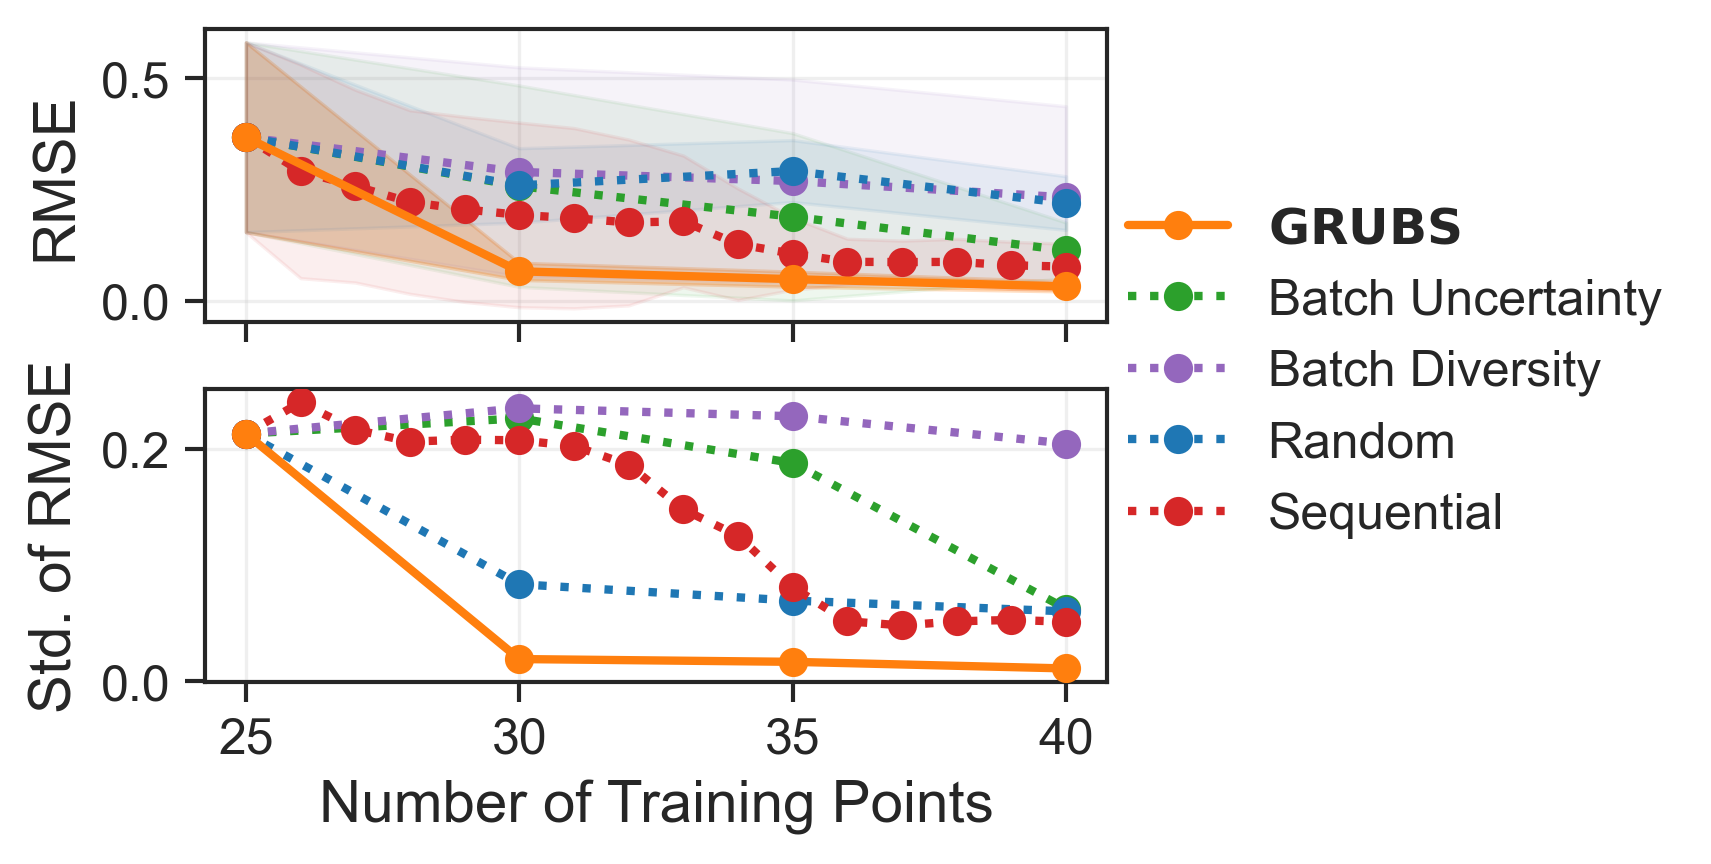


Final RMSE values (mean ± std):
$\bf{GRUBS}$: 0.0322 ± 0.0112 (at 40 points)
Batch Uncertainty: 0.1131 ± 0.0626 (at 40 points)
Batch Diversity: 0.2323 ± 0.2045 (at 40 points)
Random: 0.2194 ± 0.0602 (at 40 points)
Sequential: 0.0768 ± 0.0513 (at 40 points)


In [12]:
def plot_rmse_summary(rmse_results, methods, preset=HALF_FIG):
    """Clean RMSE visualization with HALF_FIG styling."""

    preset.apply()

    # ---- METHOD LABELS ----
    label_map = {
        "GRUBS": r"$\bf{GRUBS}$",
        "UNC": "Batch Uncertainty",
        "DIV": "Batch Diversity",
        "sequential": "Sequential",
        "random": "Random"
    }

    colors = {
        "GRUBS": "tab:orange",
        "DIV": "tab:purple",
        "UNC": "tab:green",
        "sequential": "tab:red",
        "random": "tab:blue"
    }

    fig, axs = plt.subplots(
        2, 1,
        figsize=preset.figsize,
        dpi=preset.dpi,
        sharex=True
    )

    # =========================
    # TOP: MEAN RMSE
    # =========================
    for method in methods:
        x = rmse_results[method]['x']
        rmse_array = rmse_results[method]['rmse']

        means = np.mean(rmse_array, axis=0)
        stds = np.std(rmse_array, axis=0)

        color = colors[method]
        label = label_map.get(method, method)

        if method == "GRUBS": 
            zorder=5 
        else: 
            zorder=3

        axs[0].plot(
            x,
            means,
            linestyle='-'if method == "GRUBS" else ':',
            linewidth=preset.linewidth,
            color=color,
            label=label,
            zorder=zorder,
            marker='o',
            markersize=preset.markersize
        )

        axs[0].fill_between(
            x,
            means - stds,
            means + stds,
            color=color,
            alpha=0.25 if method == "GRUBS" else 0.08,
            zorder=2
        )

    axs[0].set_ylabel("RMSE", fontsize=preset.labelsize)
    axs[0].tick_params(labelsize=preset.ticksize)
    axs[0].grid(True, alpha=0.3)

    # =========================
    # BOTTOM: VARIABILITY
    # =========================
    for method in methods:
        x = rmse_results[method]['x']
        rmse_array = rmse_results[method]['rmse']

        stds = np.std(rmse_array, axis=0)

        color = colors[method]
        label = label_map.get(method, method)

        if method == "GRUBS": 
            zorder=5 
        else: 
            zorder=3

        axs[1].plot(
            x,
            stds,
            linestyle='-'if method == "GRUBS" else ':',
            linewidth=preset.linewidth,
            color=color,
            alpha=1,
            label=label,
            zorder=zorder,
            marker='o',
            markersize=preset.markersize
        )

    axs[1].set_xlabel("Number of Training Points", fontsize=preset.labelsize)
    axs[1].set_ylabel("Std. of RMSE", fontsize=preset.labelsize)
    axs[1].tick_params(labelsize=preset.ticksize)
    axs[1].grid(True, alpha=0.3)

    handles, labels = axs[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=1,
        fontsize=preset.legendsize,
        frameon=False,
        bbox_to_anchor=(1.2, 0.8)  # slightly above plot
    )

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

    # =========================
    # PRINT FINAL VALUES
    # =========================
    print("\nFinal RMSE values (mean ± std):")
    for method in methods:
        x = rmse_results[method]['x']
        rmse_array = rmse_results[method]['rmse']

        final_mean = np.mean(rmse_array[:, -1])
        final_std = np.std(rmse_array[:, -1])

        label = label_map.get(method, method)
        print(f"{label}: {final_mean:.4f} ± {final_std:.4f} (at {x[-1]} points)")
plot_rmse_summary(rmse_results, methods, preset=HALF_FIG)

In [16]:
import os
import pickle
import numpy as np
import torch

def run_and_cache_method(method, cache_dir):
    """
    Runs sampling ONCE and caches everything needed for plotting.
    """

    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, f"{method}.pkl")

    # =========================
    # RETURN CACHE IF EXISTS
    # =========================
    if os.path.exists(cache_path):
        print(f"[LOAD] {method} from cache")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print(f"[RUN] {method} (no cache found)")

    np.random.seed(42)
    torch.manual_seed(42)

    # ---- init data ----
    input_sampler = InputGenerator(bounds_2d, ndim, seed=42)
    init_inputs, init_targets = generator.generate(
        input_sampler.uniformly_sample(initial_points)
    )

    # ---- model ----
    regressor = DeepEnsembleRegressor(
        n_estimators=5,
        hidden_sizes=[100, 100],
        epochs=500,
        learning_rate=0.001,
        batch_size=32,
        random_seed=42
    )

    # ---- sampler ----
    if method == "random":
        sampler = BaseSampler(
            directory=f"./results/{method}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches,
            n_batch_points=batch_size,
            initial_inputs=init_inputs,
            initial_targets=init_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=45
        )

    elif method == "sequential":
        sampler = GRUBSSampler(
            directory=f"./results/{method}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches * batch_size,
            n_batch_points=1,
            initial_inputs=init_inputs,
            initial_targets=init_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=45,
            n_initial_samples=1000,
            n_to_optimize=5,
            optimization_steps=10,
            opt_lr=0.001,
            mode="UNC"
        )

    else:
        sampler = GRUBSSampler(
            directory=f"./results/{method}",
            regressor=regressor,
            generator=generator,
            bounds=bounds_2d,
            n_iterations=batches,
            n_batch_points=batch_size,
            initial_inputs=init_inputs,
            initial_targets=init_targets,
            test_inputs=test_inputs,
            test_targets=test_targets,
            random_seed=45,
            n_initial_samples=1000,
            n_to_optimize=5,
            optimization_steps=10,
            opt_lr=0.001,
            mode=method
        )

    sampler.sample()

    # =========================
    # FINAL DATA
    # =========================
    final_inputs = sampler.x_exact[
        :sampler.n_initial_points + sampler._iteration * sampler.n_batch_points + sampler.n_batch_points
    ]

    num_init = len(init_inputs)
    new_points = final_inputs[num_init:, :2]

    # =========================
    # GRID PREDICTION
    # =========================
    Xg, Yg = np.meshgrid(
        np.linspace(bounds_2d[0, 0], bounds_2d[1, 0], 120),
        np.linspace(bounds_2d[0, 1], bounds_2d[1, 1], 120)
    )

    grid = np.column_stack([Xg.ravel(), Yg.ravel()])

    try:
        grid_scaled = sampler.input_scaler.transform(grid)
        mean, _, _ = sampler.regressor.predict(grid_scaled)

        Z = sampler.output_scaler.inverse_transform(
            mean.reshape(-1, 1)
        ).ravel().reshape(Xg.shape)
    except:
        Z = np.zeros_like(Xg)

    cache = {
        "init_inputs": init_inputs,
        "new_points": new_points,
        "Xg": Xg,
        "Yg": Yg,
        "Z": Z
    }

    with open(cache_path, "wb") as f:
        pickle.dump(cache, f)

    return cache

In [30]:
def plot_final_distributions_cached(methods, cache_dir="./plot_cache"):
    preset = HALF_FIG.apply()

    label_map = {
        "GRUBS": "GRUBS",
        "UNC": "Batch Uncertainty",
        "DIV": "Batch Diversity",
        "sequential": "Sequential",
        "random": "Random"
    }

    method_colors = {
        "GRUBS": "C1",
        "UNC": "C0",
        "DIV": "C2",
        "sequential": "C3",
        "random": "C4"
    }

    fig, axes = plt.subplots(2, 3)
    axes = axes.flatten()

    # =========================
    # Ground truth
    # =========================
    ax = axes[0]

    X = methods  # dummy override not used

    x_range = np.linspace(bounds_2d[0, 0], bounds_2d[1, 0], 120)
    y_range = np.linspace(bounds_2d[0, 1], bounds_2d[1, 1], 120)
    Xg, Yg = np.meshgrid(x_range, y_range)

    Z = generator.generate(np.column_stack([Xg.ravel(), Yg.ravel()]))[1]
    Z = Z.reshape(Xg.shape)

    cf = ax.contourf(Xg, Yg, Z, levels=20, cmap="viridis")
    ax.set_title("Ground Truth", fontsize=preset.titlesize)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    # =========================
    # Methods
    # =========================
    for idx, method in enumerate(methods, start=1):
        ax = axes[idx]

        cache = run_and_cache_method(method, cache_dir)

        init_inputs = cache["init_inputs"]
        new_points = cache["new_points"]
        Xg = cache["Xg"]
        Yg = cache["Yg"]
        Z = cache["Z"]

        ax.contourf(Xg, Yg, Z, levels=20, cmap="viridis")

        ax.scatter(
            init_inputs[:, 0],
            init_inputs[:, 1],
            c="black",
            s=preset.markersize**2,
            marker="o",
            edgecolors="white",
            linewidth=0.8
        )

        ax.scatter(
            new_points[:, 0],
            new_points[:, 1],
            c=method_colors[method],
            s=2 * preset.markersize**2,
            marker="o",
            edgecolors="white",
            linewidth=0.8
        )

        ax.set_title(label_map[method], fontsize=preset.titlesize)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)

    plt.tight_layout()

    fig.subplots_adjust(right=0.88)

    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

    cbar = fig.colorbar(cf, cax=cbar_ax)
    cbar.set_label("Function Value", fontsize=preset.labelsize)
    cbar.ax.tick_params(labelsize=preset.ticksize)
    plt.show()

[LOAD] GRUBS from cache
[LOAD] UNC from cache
[LOAD] DIV from cache
[LOAD] sequential from cache
[LOAD] random from cache


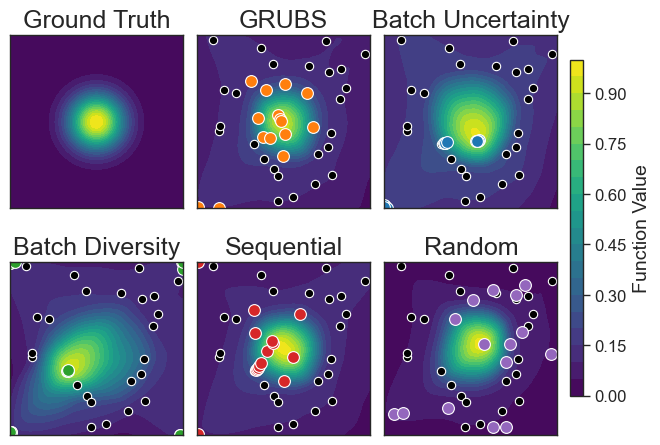

In [31]:
methods = ["GRUBS", "UNC", "DIV", "sequential", "random"]
plot_final_distributions_cached(
    methods,
    cache_dir="./plot_cache"
)